In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#importing the boston house price prediction dataset
from sklearn.datasets import load_boston
#importing train_test_split to split the dataset into train and test set
from sklearn.model_selection import train_test_split

In [3]:
#storing the dataset in a variable
dataset = load_boston()

In [4]:
#store the dataset as a pandas dataframe
df = pd.DataFrame(data = dataset.data, columns = dataset.feature_names)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [5]:
df["MEDV"] = dataset.target
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [6]:
X = pd.concat((df["LSTAT"], df["RM"]), axis = 1)
X.head()

,LSTAT,RM
0,4.98,6.575
1,9.14,6.421
2,4.03,7.185
3,2.94,6.998
4,5.33,7.147


In [7]:
y = pd.DataFrame(df["MEDV"])
y.tail()

,MEDV
501,22.4
502,20.6
503,23.9
504,22.0
505,11.9


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [9]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(404, 2) (404, 1)
(102, 2) (102, 1)


In [10]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(404, 2) (404, 1)
(102, 2) (102, 1)


In [11]:
def update_w_and_b(x, y, w, b, alpha, momentw, momentb, sqw, sqb, beta1, beta2, epsilon, epochs):
    dl_dw = 0
    dl_db = 0
    N = len(x)
    mw, mb = momentw, momentb
    sw, sb = sqw, sqb
    
    for i in range(N):
        dl_dw += -2*x[i]*(y[i] - (w*x[i] +b))
        dl_db += -2*(y[i] - (w*x[i] + b))
        
    mw = (beta1*mw) - ((1 - beta1)*((1/float(N))*dl_dw))
    mb = (beta1*mb) - ((1 - beta1)*((1/float(N))*dl_db))
    
    sw = (beta2*sw) + ((1 - beta2)*((1/float(N))*dl_dw)**2)
    sb = (beta2*sb) + ((1 - beta2)*((1/float(N))*dl_db)**2)
    
    mw_hat = mw / (1 - beta1**epochs)
    mb_hat = mb / (1 - beta1**epochs)
    
    sw_hat = sw / (1 - beta2**epochs)
    sb_hat = sb / (1 - beta2**epochs)
    
    w = w + (alpha*mw_hat) / np.sqrt(sw_hat + epsilon)
    b = b + (alpha*mb_hat) / np.sqrt(sb_hat + epsilon)
    
    return w, b, mw, mb, sw, sb

In [12]:
from matplotlib.pyplot import figure
def train(x, y, w, b, alpha, epochs, beta1, beta2, epsilon):
    avg_loss_list = []
    w_list = []
    b_list = []
    img_list = []
    pred_val_at_diff_epoch = []
    momentw, momentb = 0, 0
    sqw, sqb = 0, 0
    for num_of_epochs in range(epochs):
        xy = pd.concat([x, y], axis = 1)
        indexes = xy.index
        rand_indexes = np.random.choice(indexes, 15)
        xtrain = []
        ytrain = []
        for i in rand_indexes:
            xtrain.append(x[i])
            ytrain.append(y[i])
        w, b, momentw, momentb, sqw, sqb = update_w_and_b(xtrain, ytrain, w, b, alpha, momentw, momentb, sqw, sqb, beta1, beta2, epsilon, num_of_epochs+1)
        if num_of_epochs%10 == 0:
            avg_loss_list.append(avg_loss(x, y, w, b))
            w_list.append(w)
            b_list.append(b)
        if num_of_epochs%5000 == 0:
            print("epoch: ", num_of_epochs,"average loss: ",avg_loss(x, y, w, b))
            figure(figsize = (15, 10))
            plt.title(f"Epoch: {num_of_epochs}")
            plt.xlabel("X")
            plt.ylabel("y")
            plt.xlim(0, 9)
            plt.ylim(0, 50)
            
            plt.scatter(x, y)
            xt = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
            yt = []
            for i in xt:
                yt.append(predict(i, w, b))
                
            plt.plot(xt, yt, color = "red")
            
            plt.savefig(f"{num_of_epochs}.png")
            img_list.append(f"{num_of_epochs}.png")
            
            plt.show()
            if avg_loss(x, y, w, b) <= 38:
                return w_list, b_list, avg_loss_list, w, b, img_list, pred_val_at_diff_epoch
            
    return w_list, b_list, avg_loss_list, w, b, img_list, pred_val_at_diff_epoch

In [13]:
def avg_loss(x, y, w, b):
    N = len(x)
    total_error = 0
    for i in range(N):
        total_error += (y[i] - (w*x[i]+b))**2
    return total_error/float(N)

In [14]:
def predict(x, w, b):
    return w*x+b

epoch:  0 average loss:  671.1473185788462


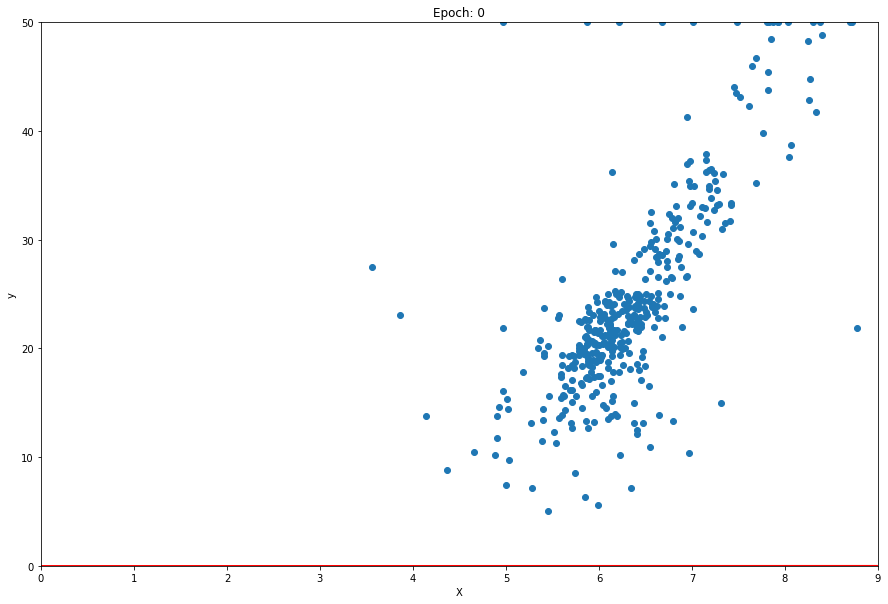

epoch:  5000 average loss:  57.25503010393295


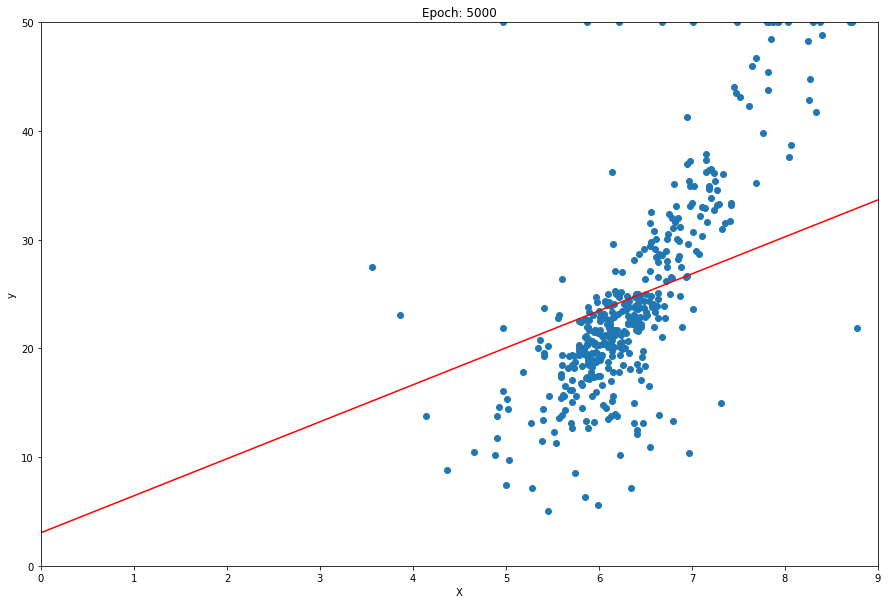

epoch:  10000 average loss:  56.165930817467384


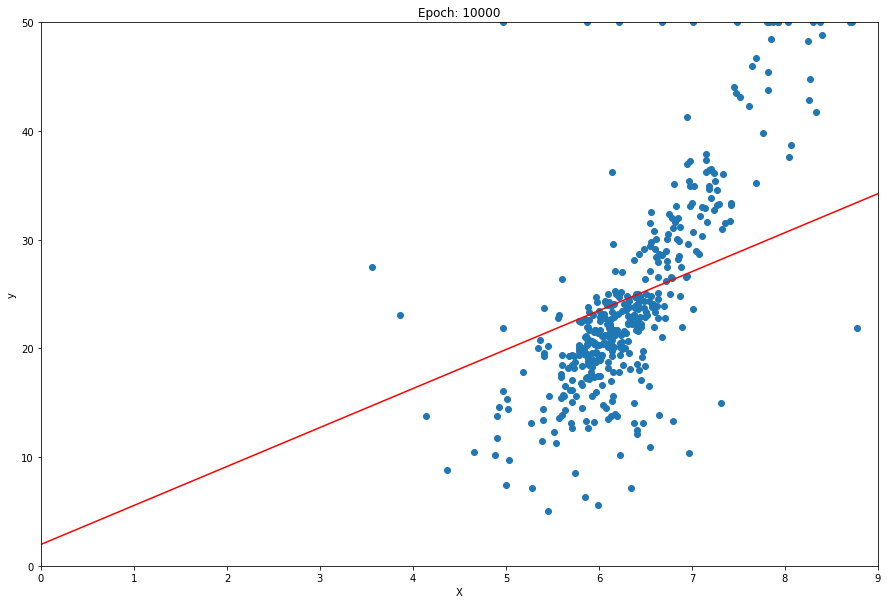

epoch:  15000 average loss:  55.14360311850149


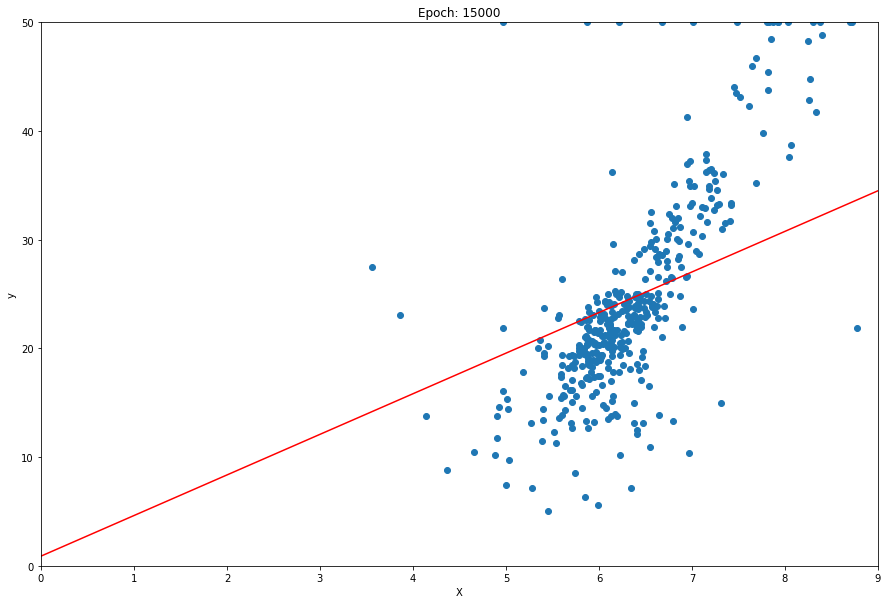

epoch:  20000 average loss:  54.142299221601036


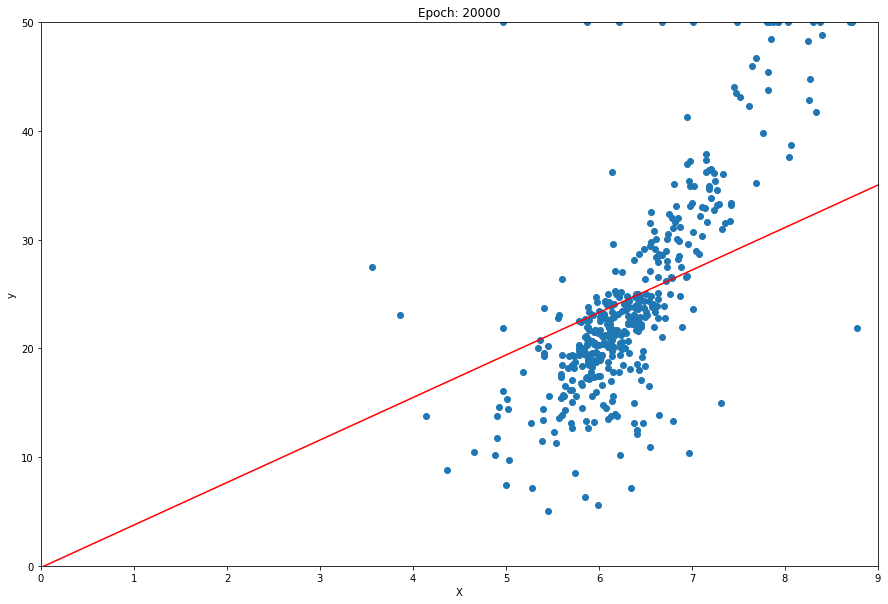

epoch:  25000 average loss:  53.20665611543407


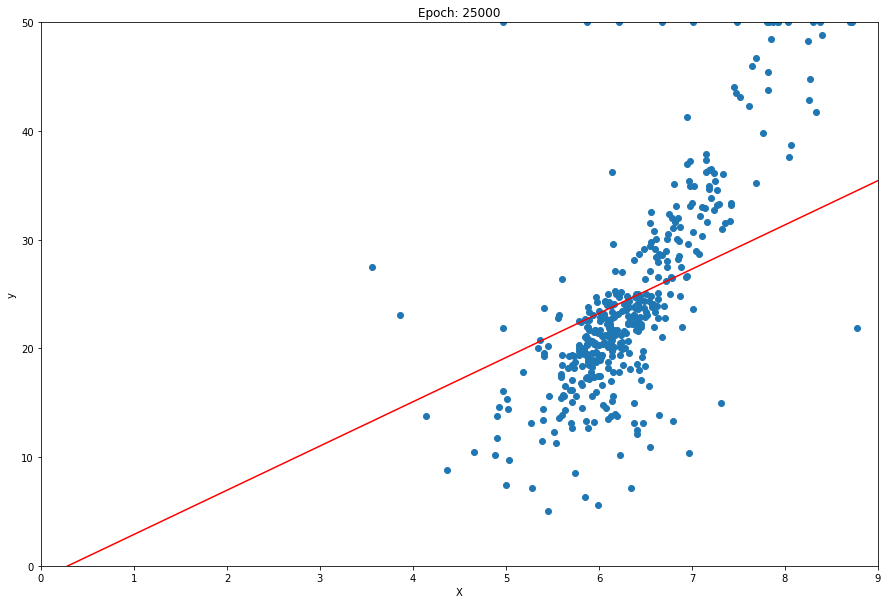

epoch:  30000 average loss:  52.34278064633935


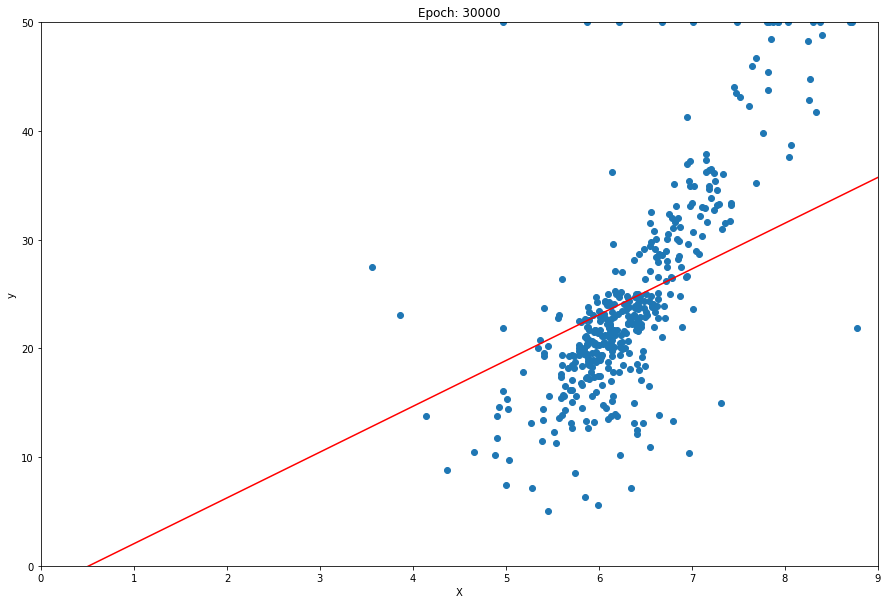

epoch:  35000 average loss:  51.502763610346996


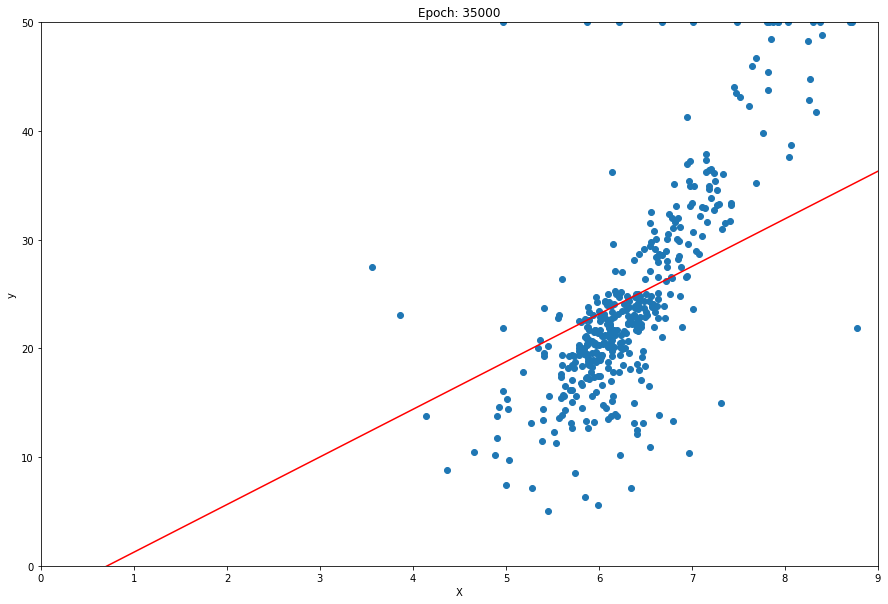

epoch:  40000 average loss:  50.722277784110794


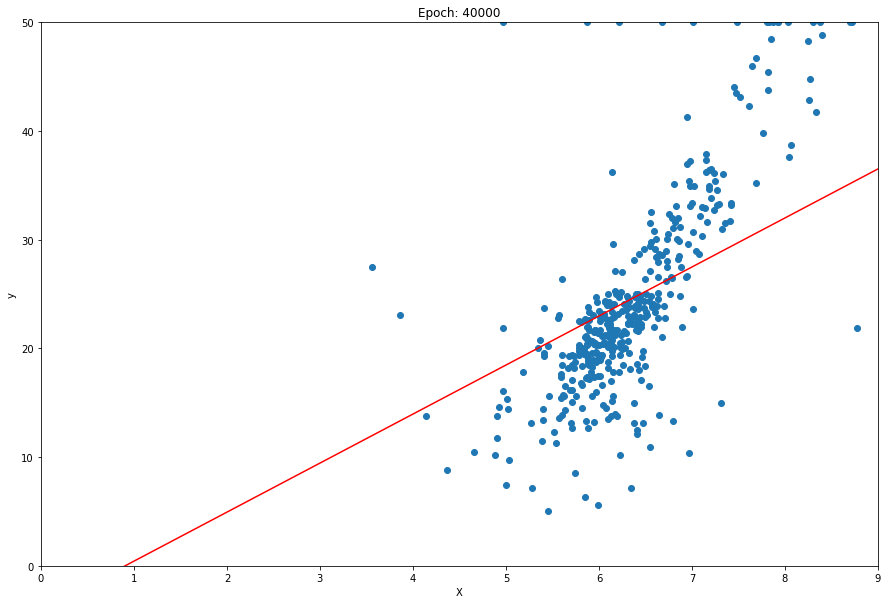

epoch:  45000 average loss:  49.98006460256129


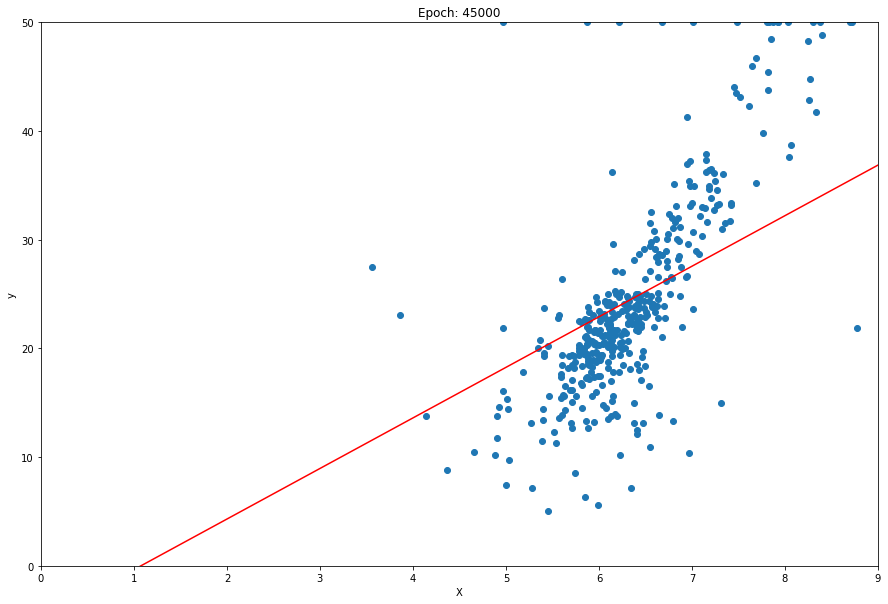

epoch:  50000 average loss:  49.2451948776264


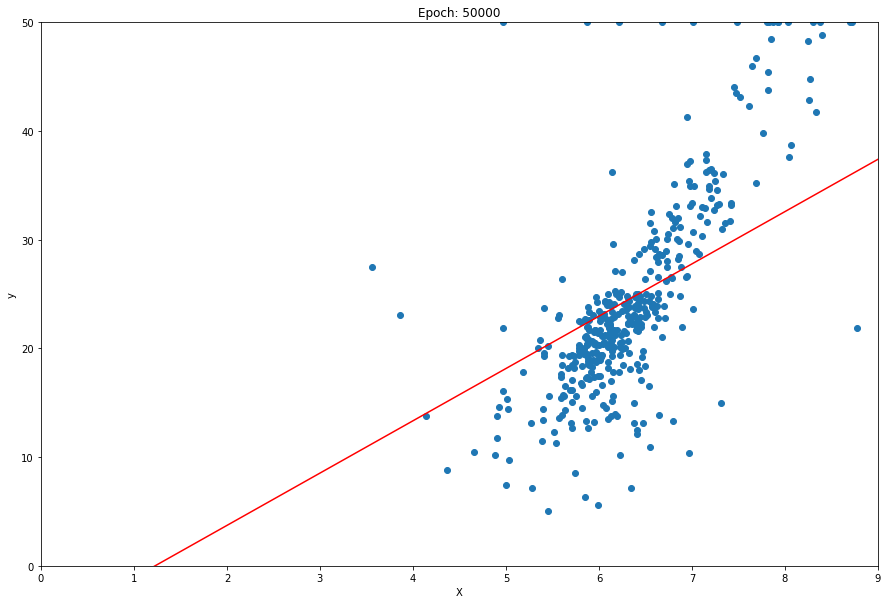

epoch:  55000 average loss:  48.55837998809144


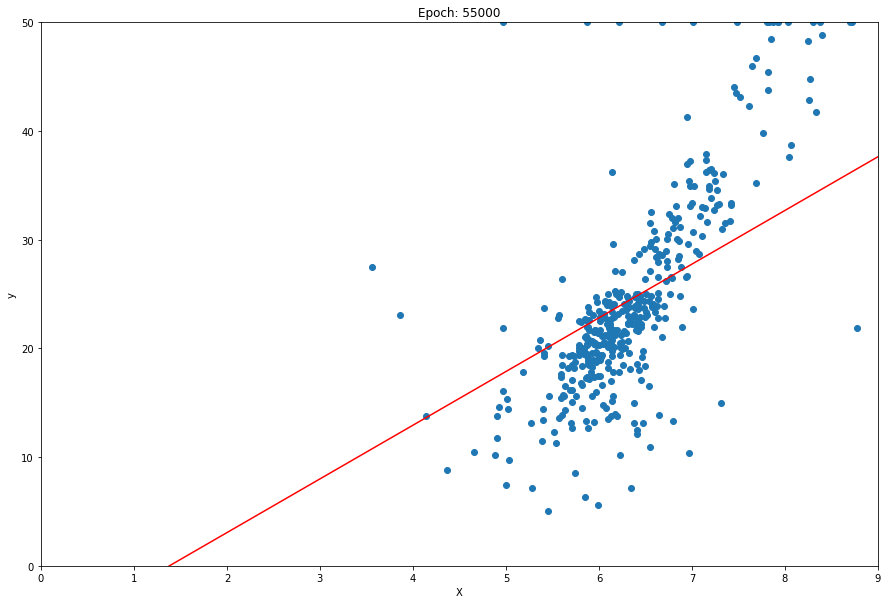

epoch:  60000 average loss:  47.93491517832051


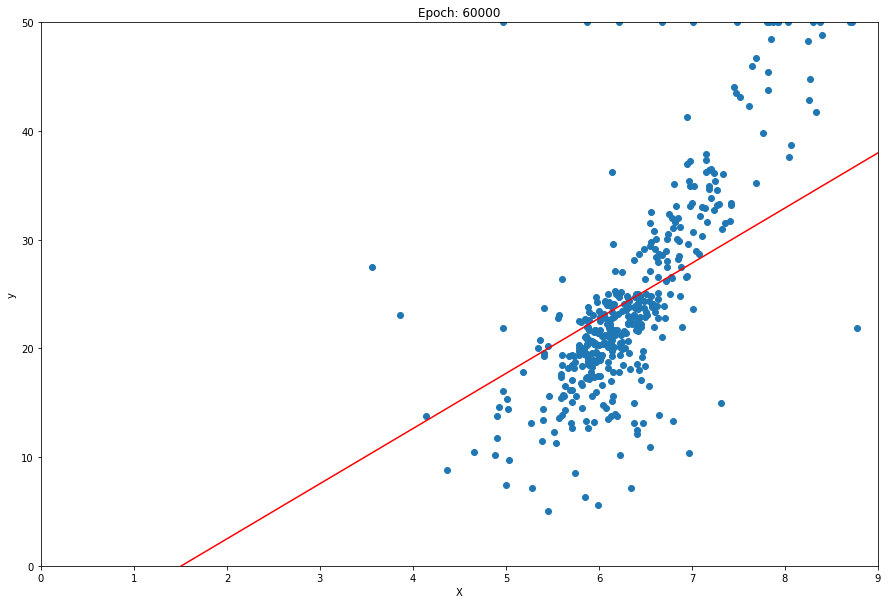

epoch:  65000 average loss:  47.32736216507877


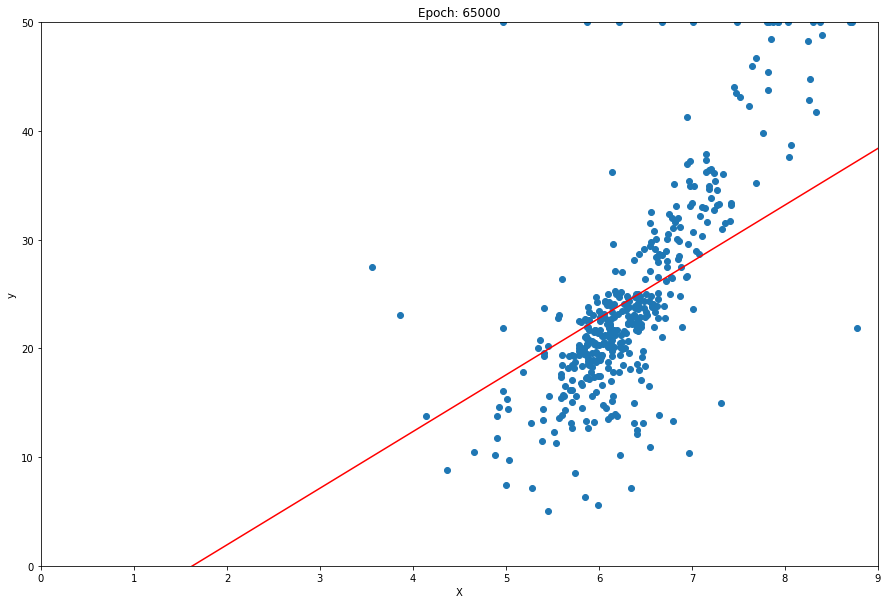

epoch:  70000 average loss:  46.750762810527775


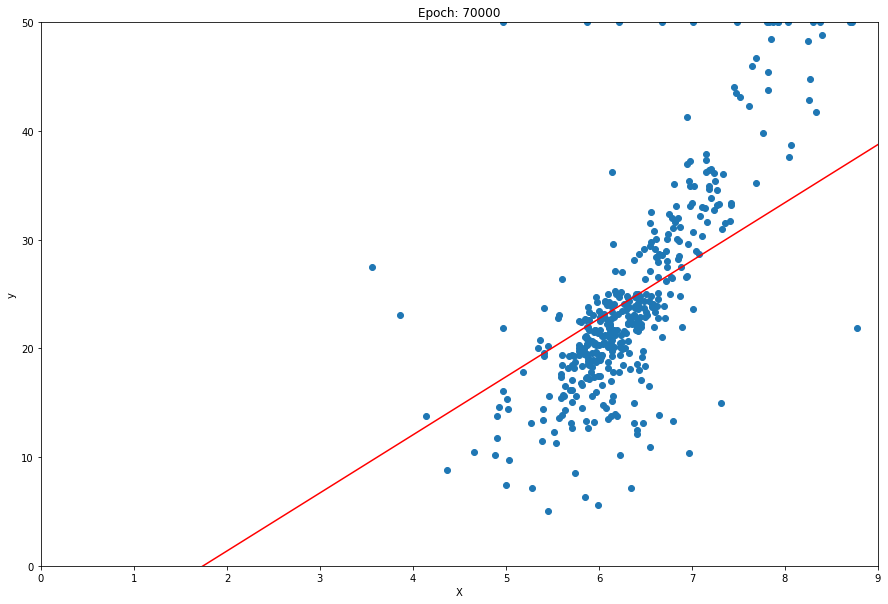

epoch:  75000 average loss:  46.21751448121683


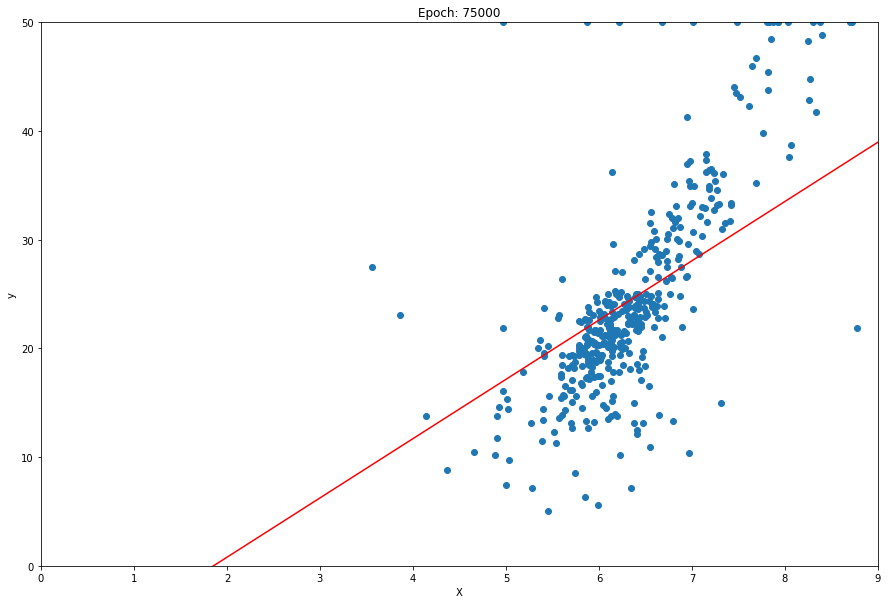

epoch:  80000 average loss:  45.719203482212116


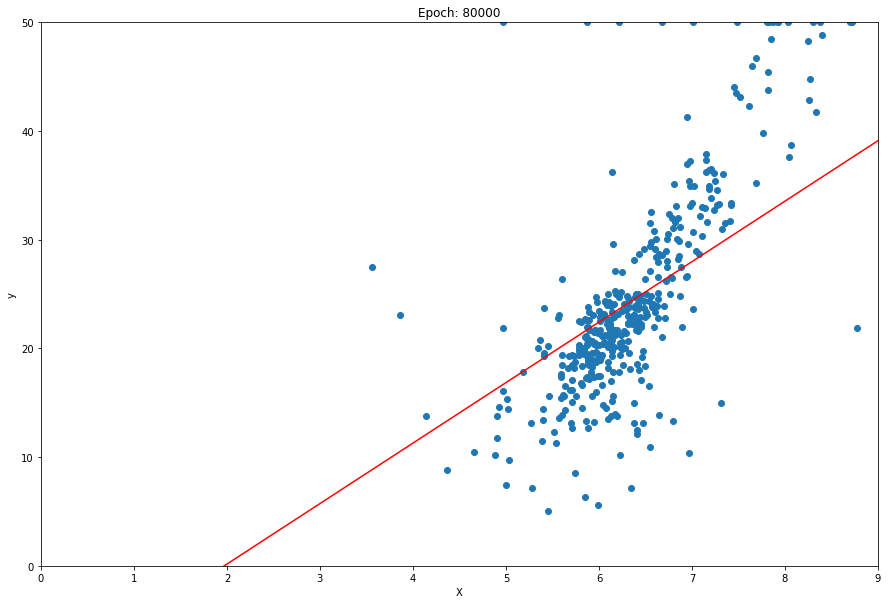

epoch:  85000 average loss:  45.18479941751789


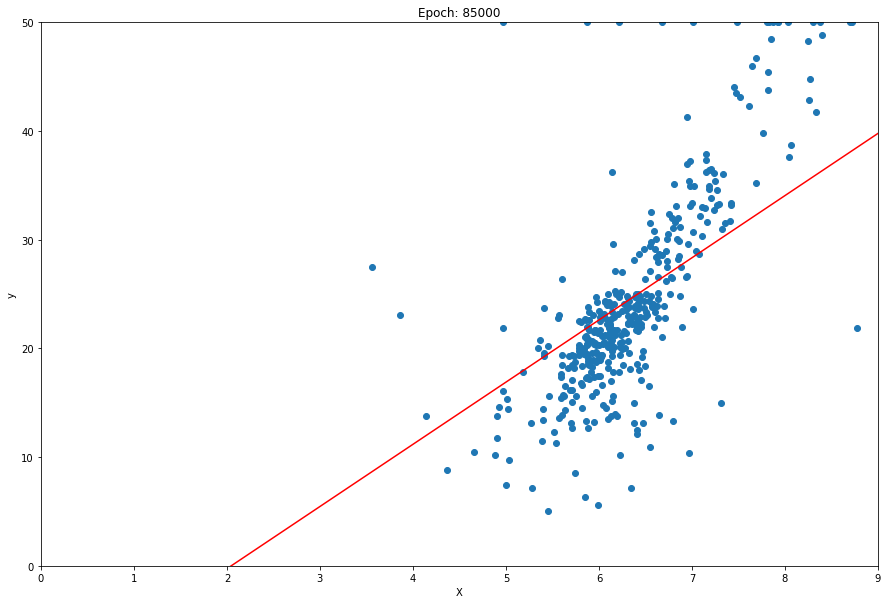

epoch:  90000 average loss:  44.71527019227144


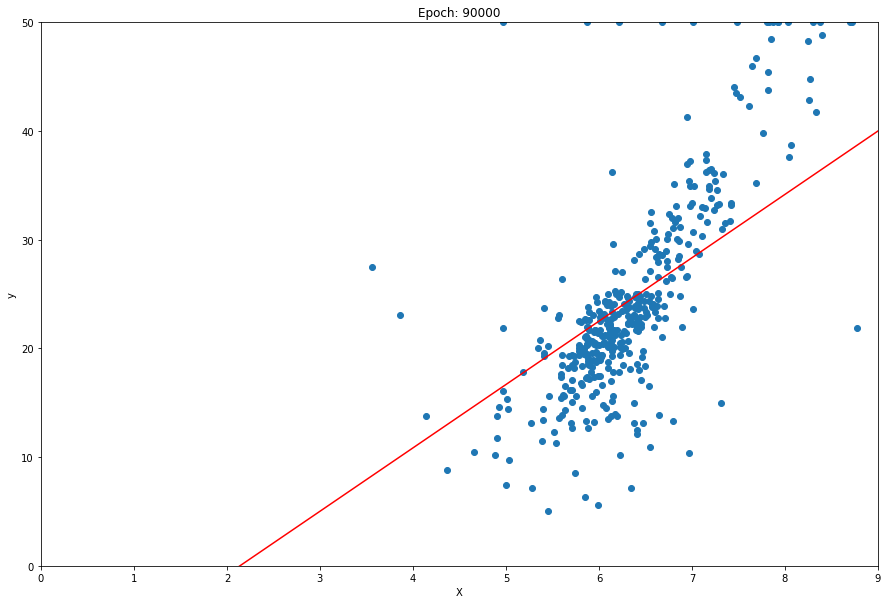

epoch:  95000 average loss:  44.27454813977738


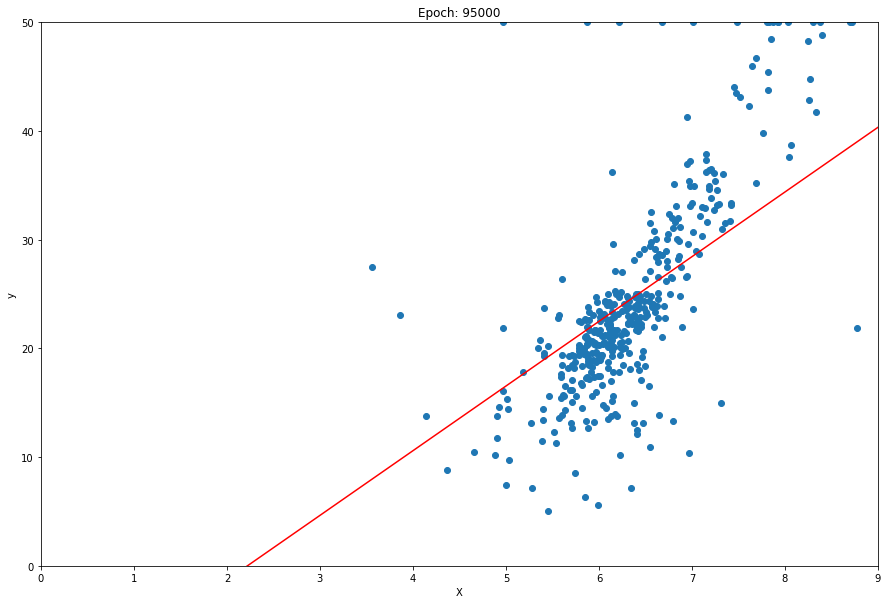

epoch:  100000 average loss:  43.871962079279776


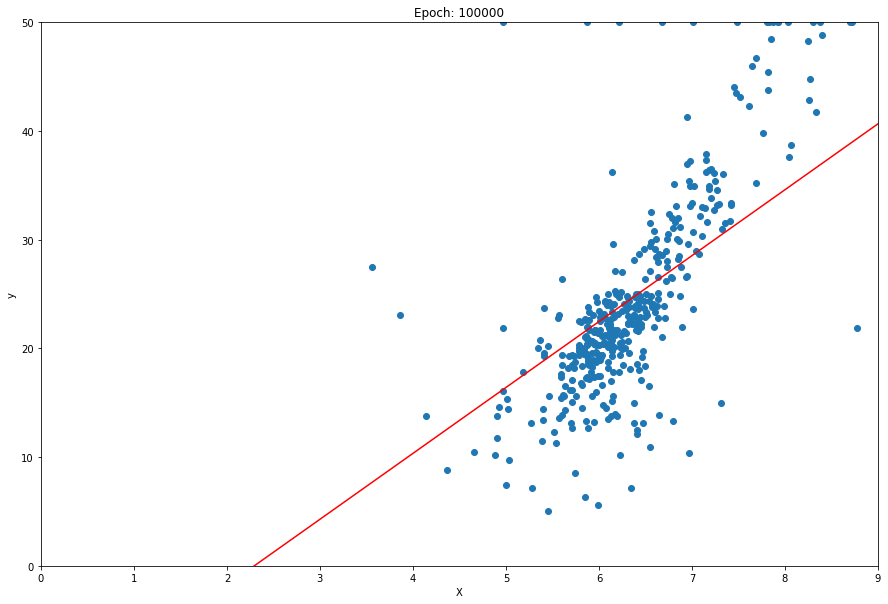

epoch:  105000 average loss:  43.495028260355575


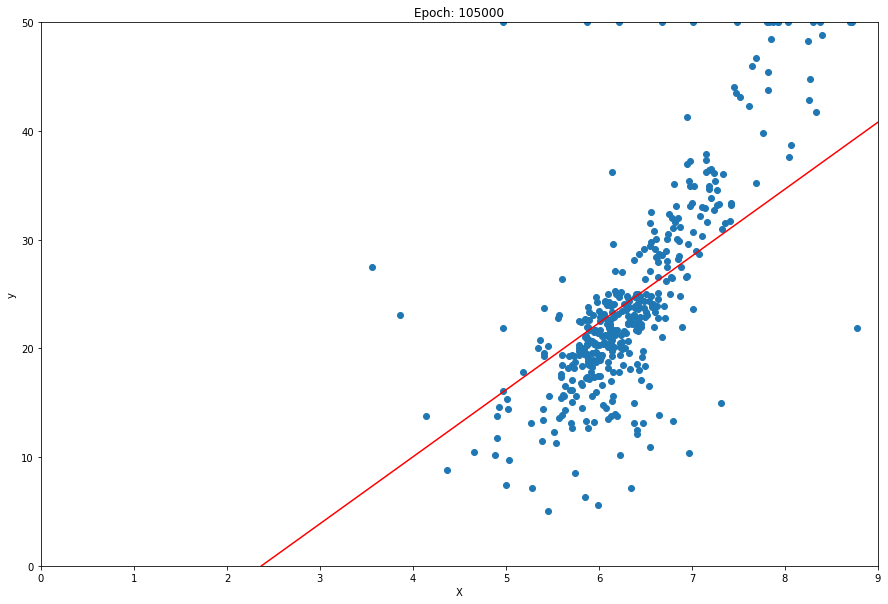

epoch:  110000 average loss:  43.12686077118073


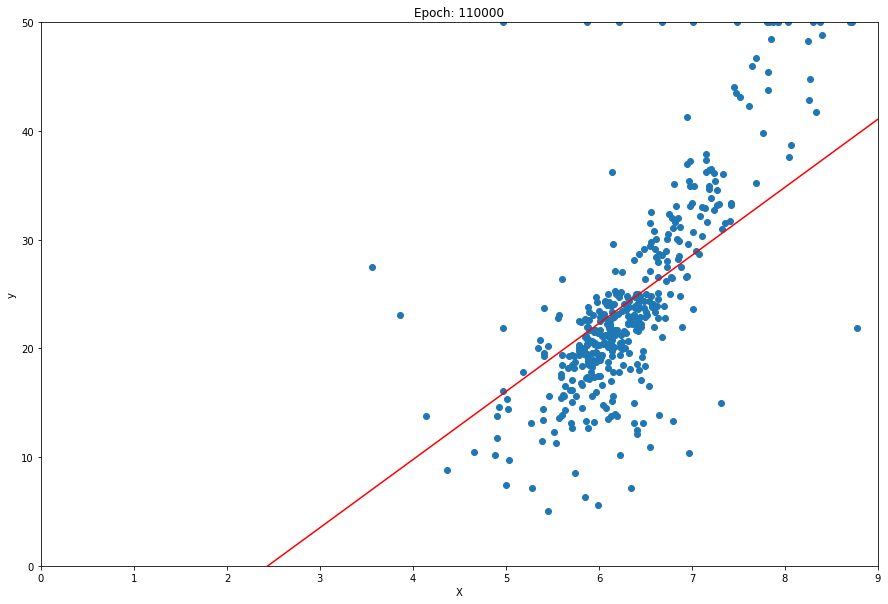

epoch:  115000 average loss:  42.779897798119684


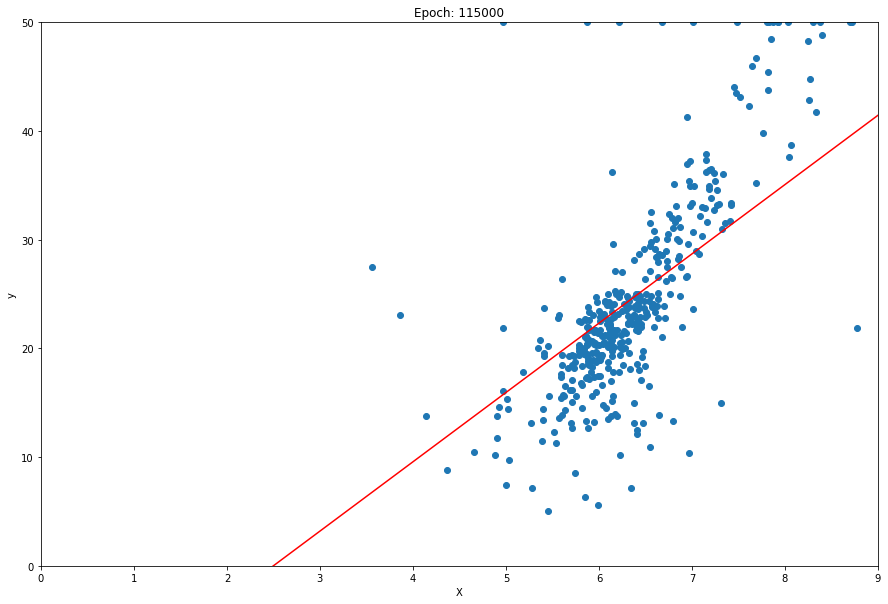

epoch:  120000 average loss:  42.47607724534821


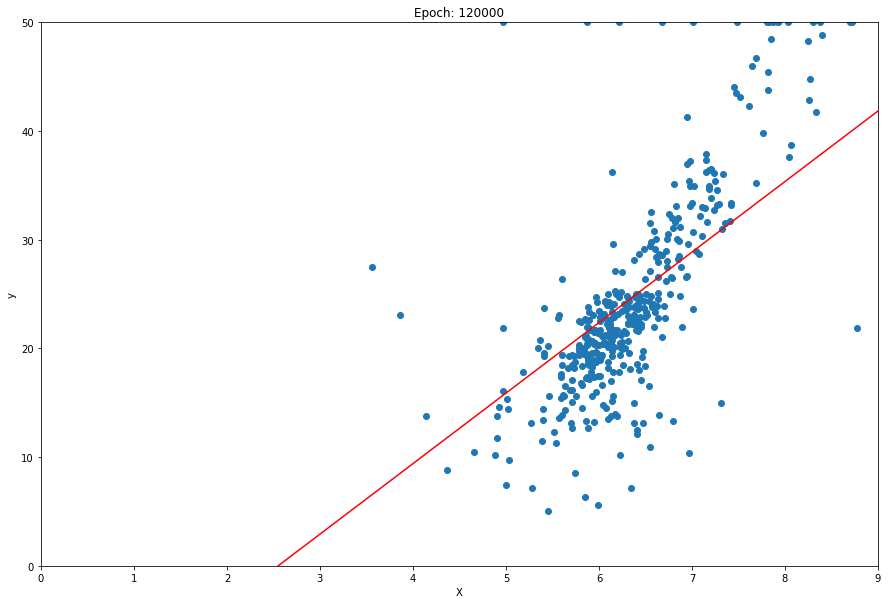

epoch:  125000 average loss:  42.165071461672476


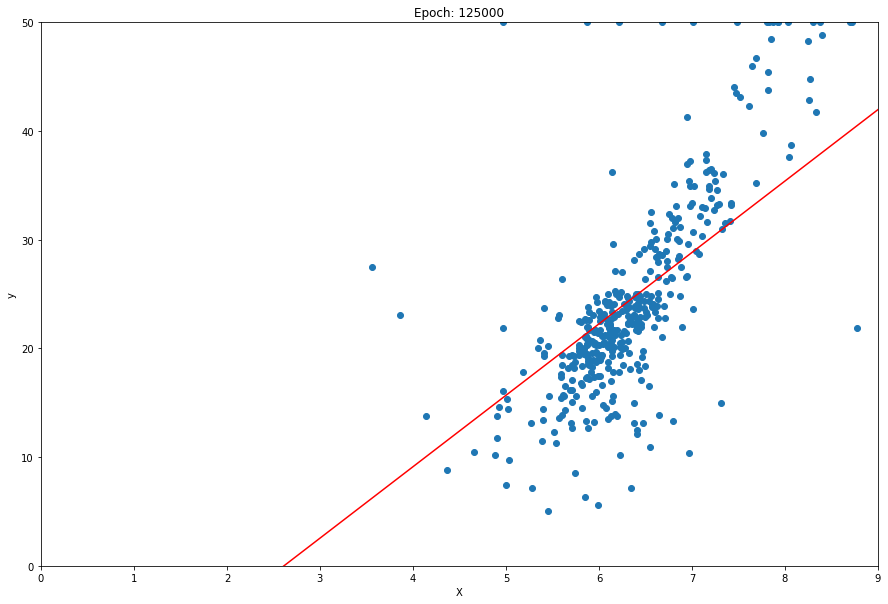

epoch:  130000 average loss:  41.888484354265266


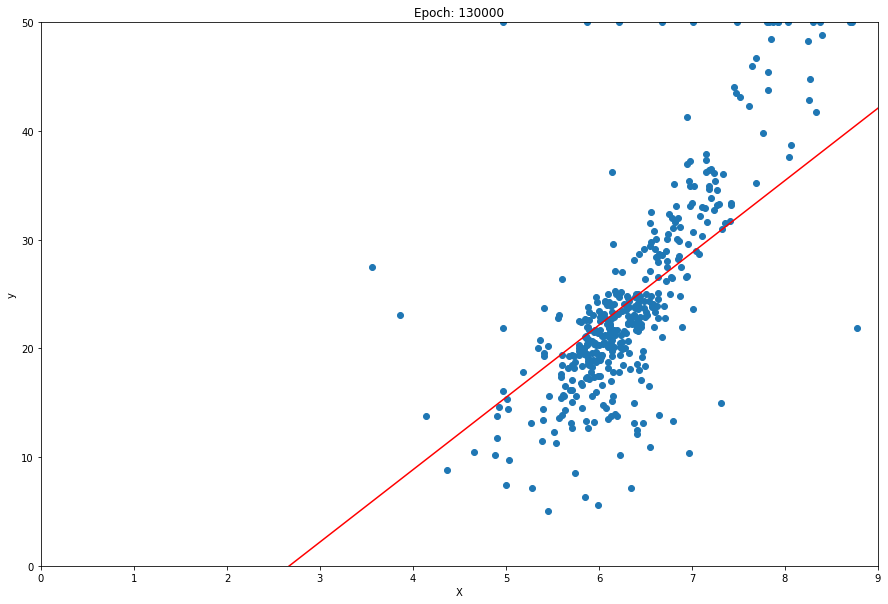

epoch:  135000 average loss:  41.62697190879615


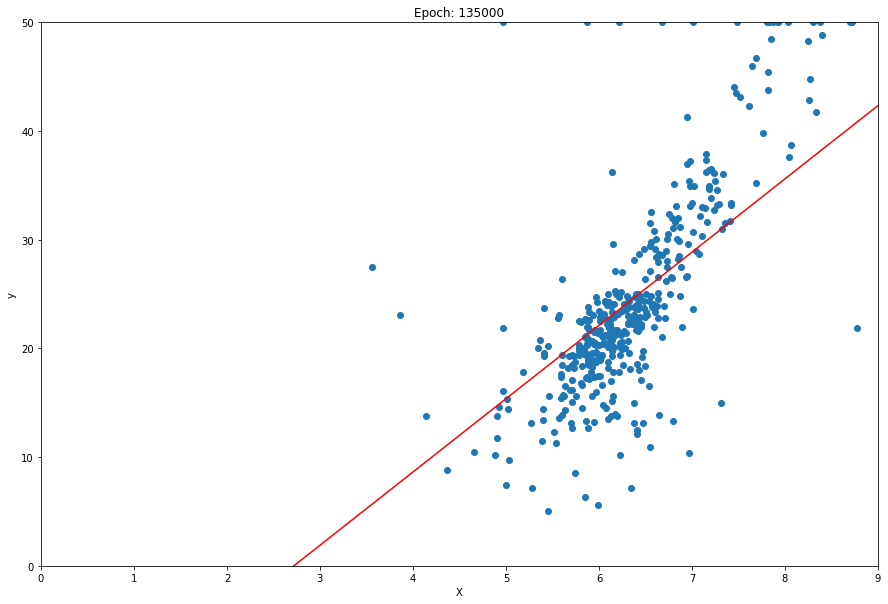

epoch:  140000 average loss:  41.382471183461945


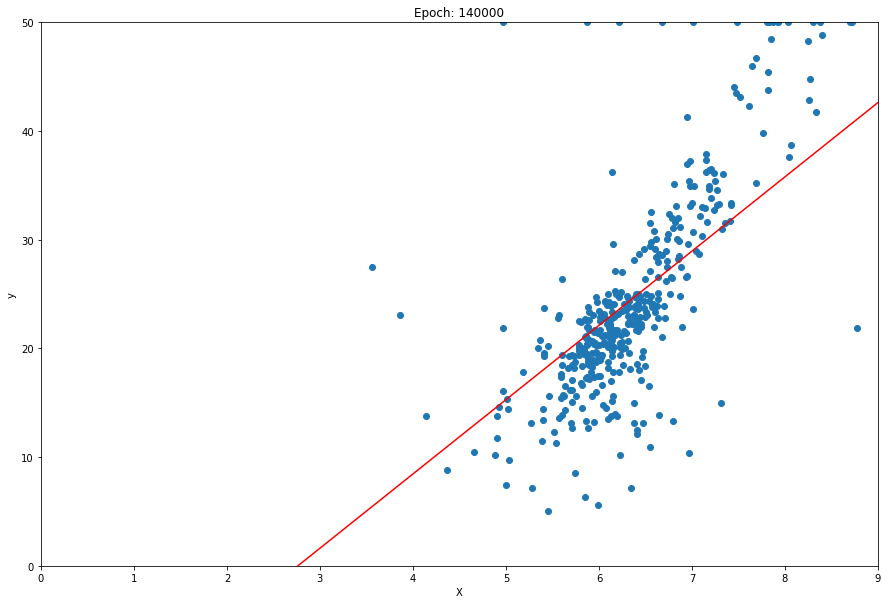

epoch:  145000 average loss:  41.1554584947916


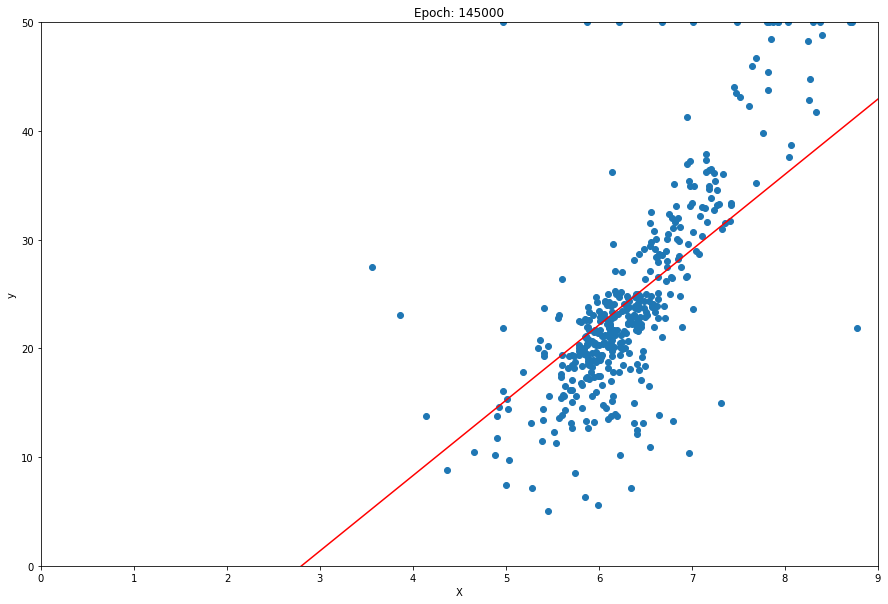

epoch:  150000 average loss:  40.945971689418684


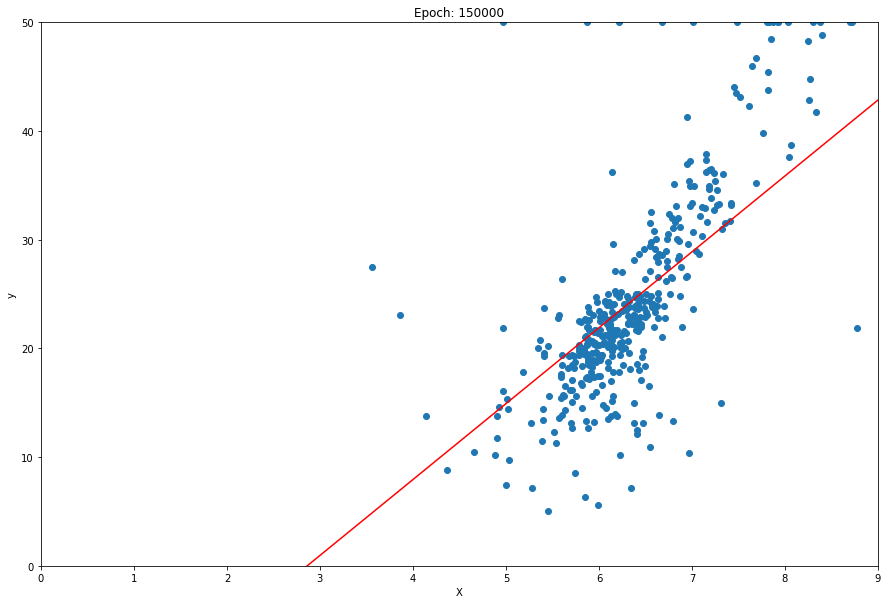

epoch:  155000 average loss:  40.718089856831305


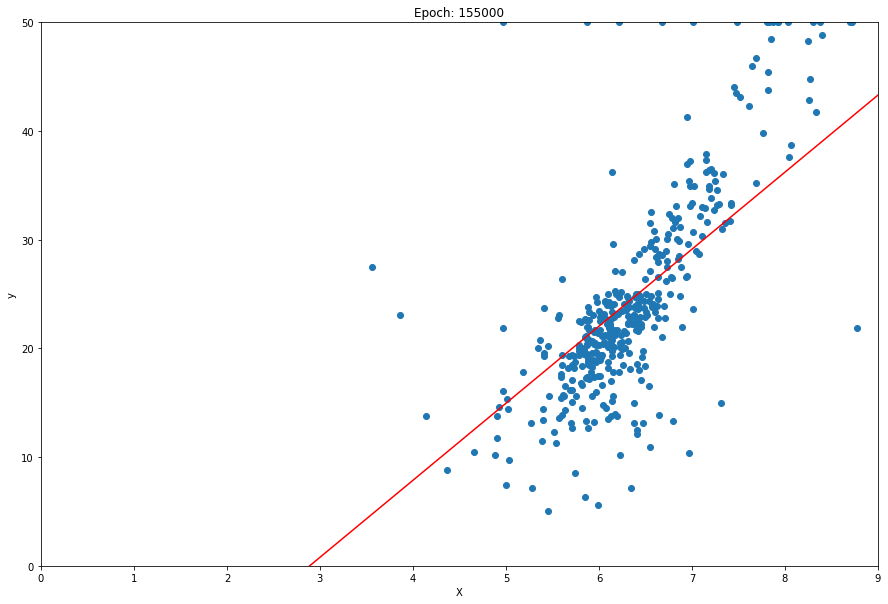

epoch:  160000 average loss:  40.53122074178854


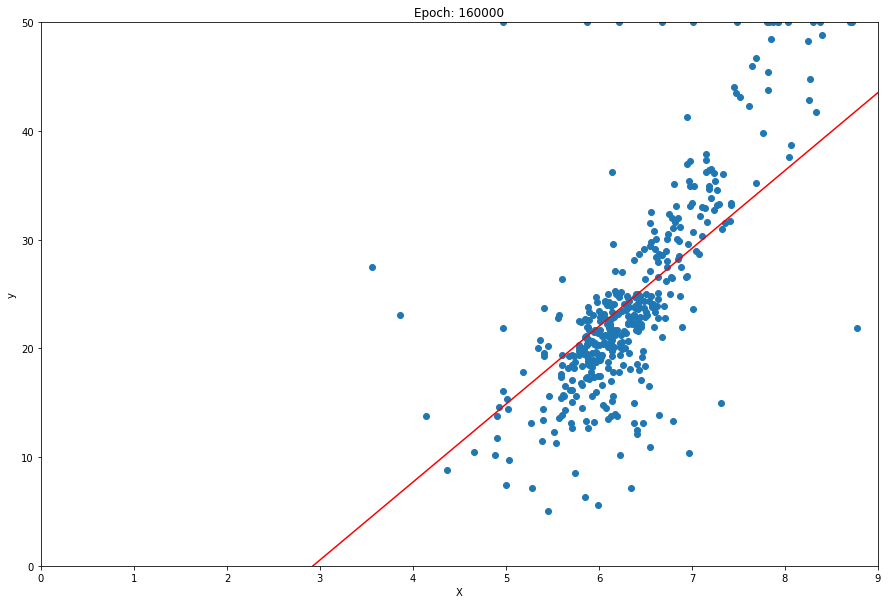

epoch:  165000 average loss:  40.3411191030211


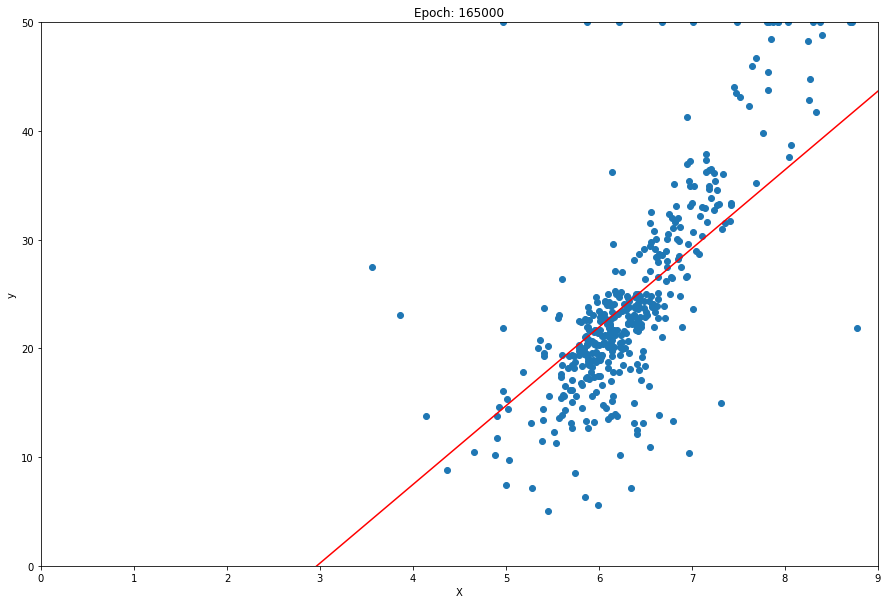

epoch:  170000 average loss:  40.17270432760501


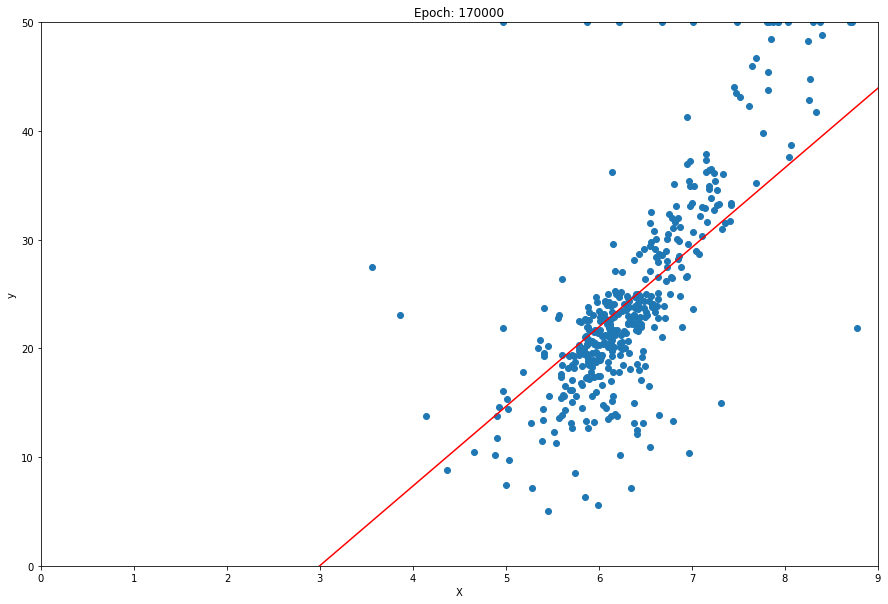

epoch:  175000 average loss:  40.01969133395002


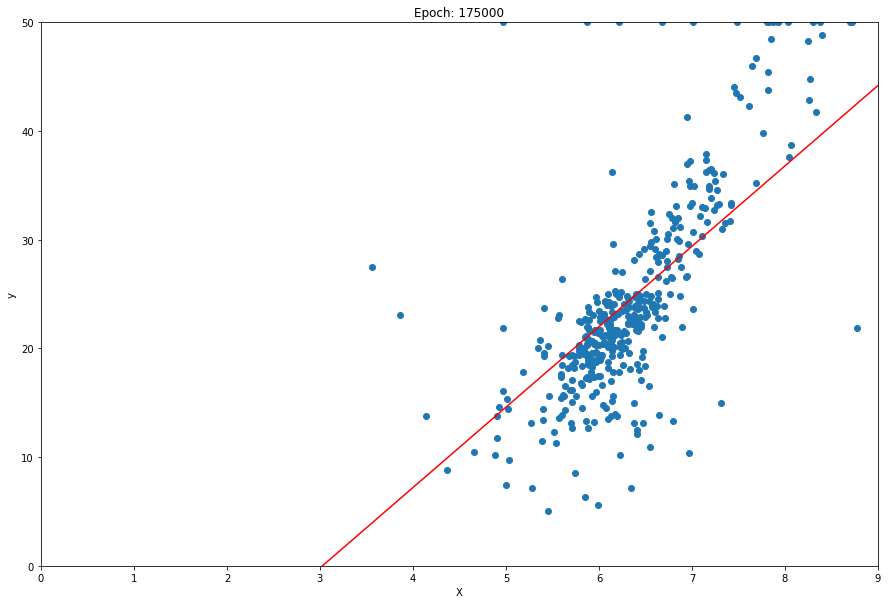

epoch:  180000 average loss:  39.872564588276056


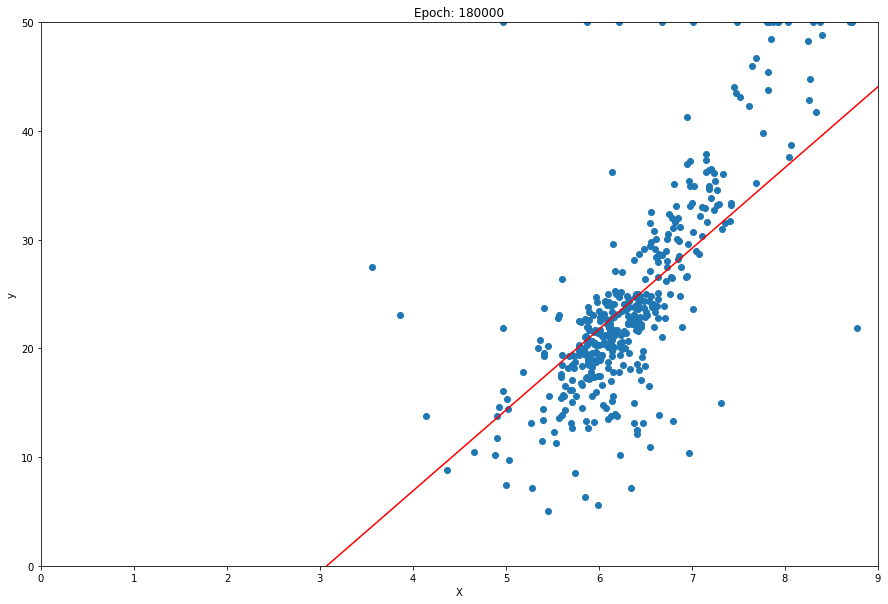

epoch:  185000 average loss:  39.72283713641833


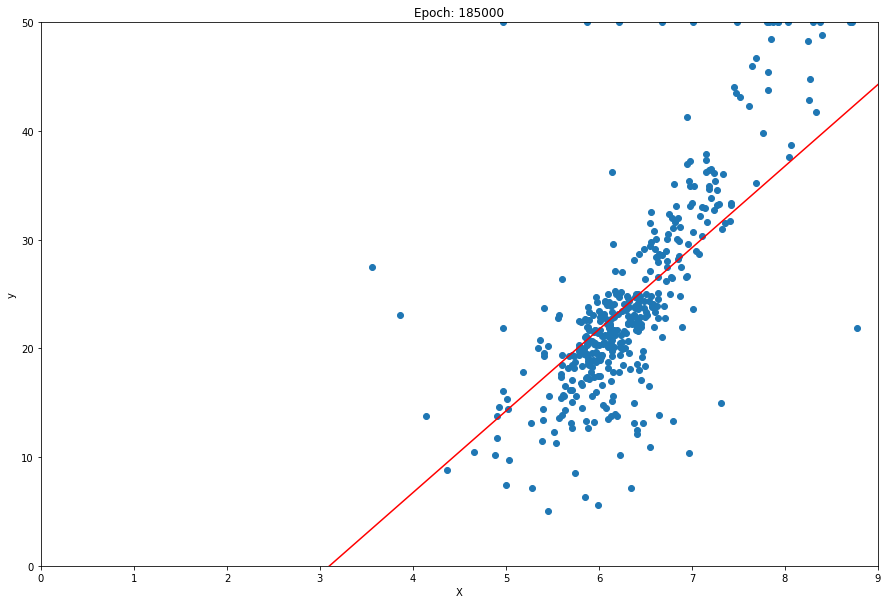

epoch:  190000 average loss:  39.59410286823471


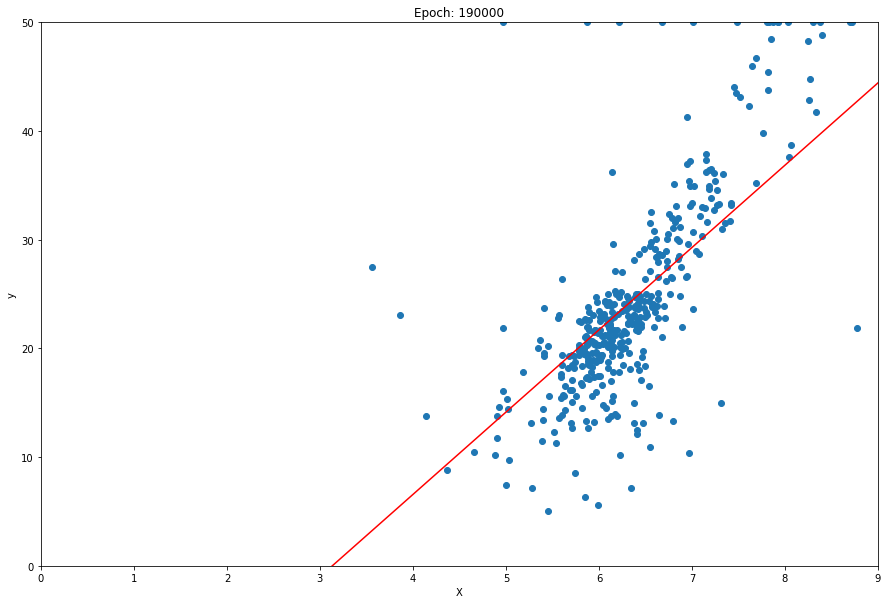

epoch:  195000 average loss:  39.47006667787327


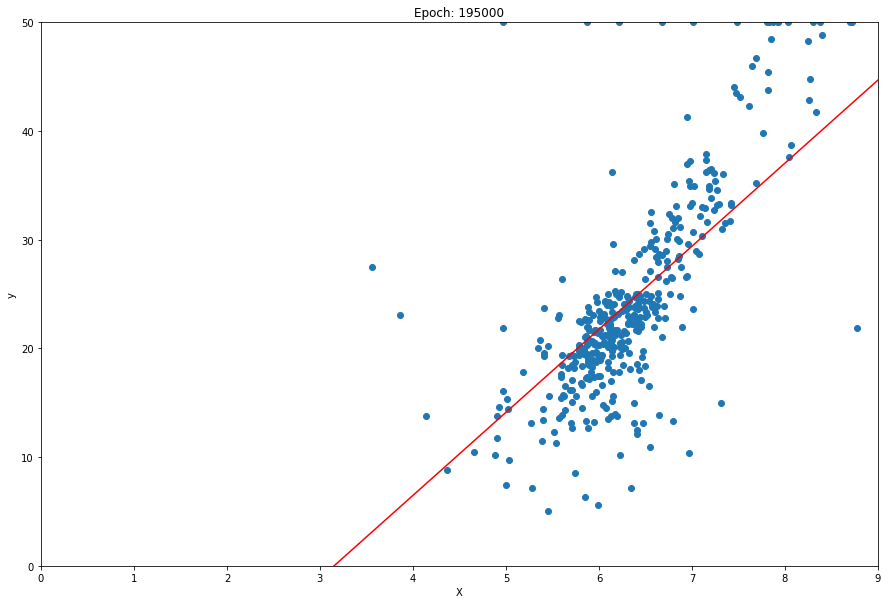

epoch:  200000 average loss:  39.35632375305606


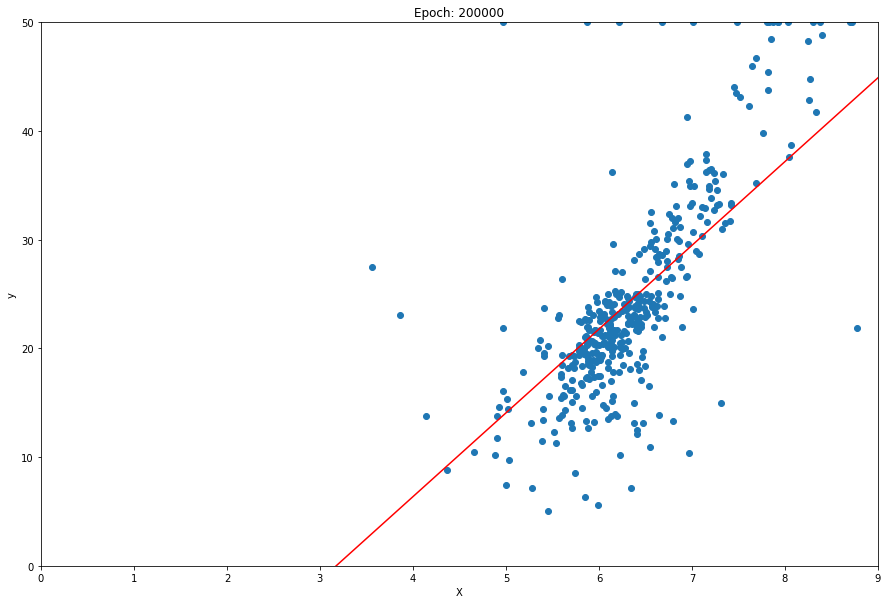

epoch:  205000 average loss:  39.259205144769844


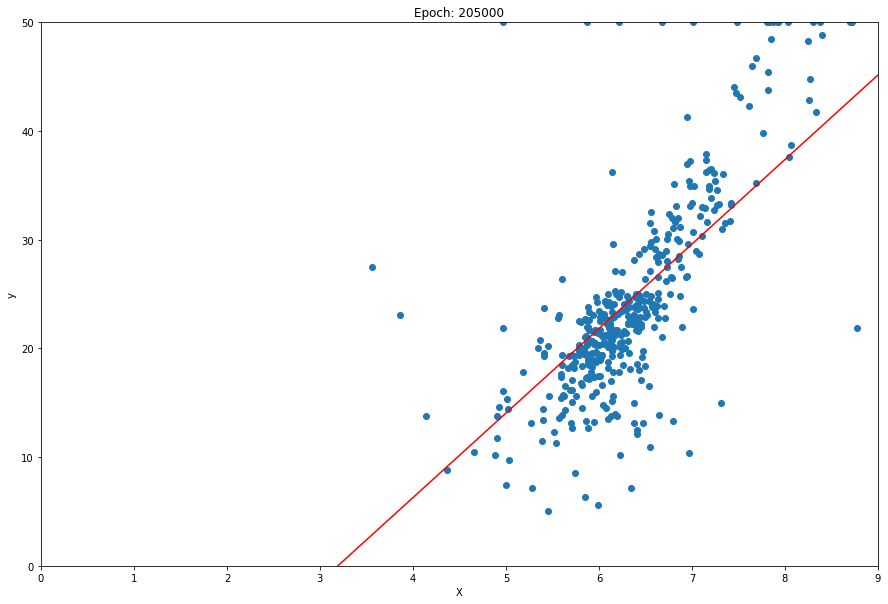

epoch:  210000 average loss:  39.15321626589032


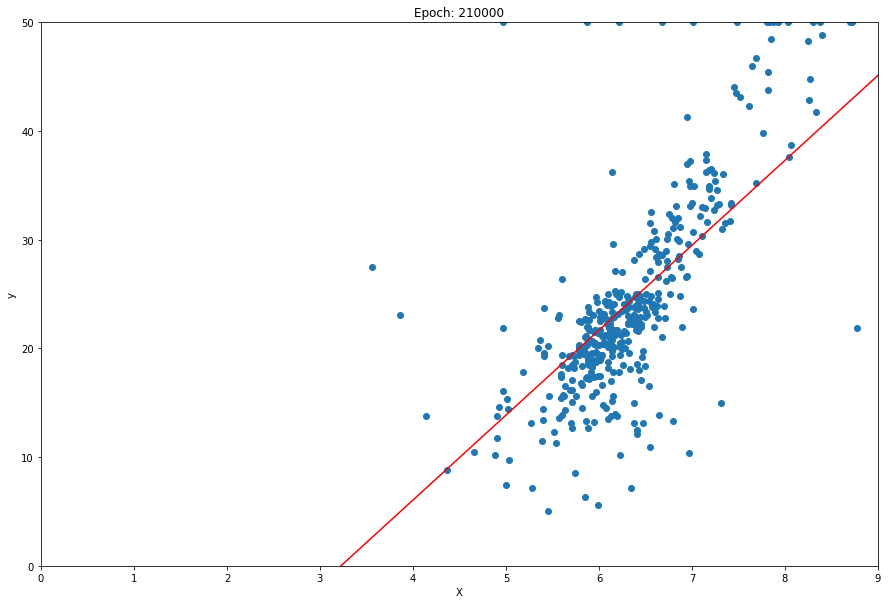

epoch:  215000 average loss:  39.06010002068447


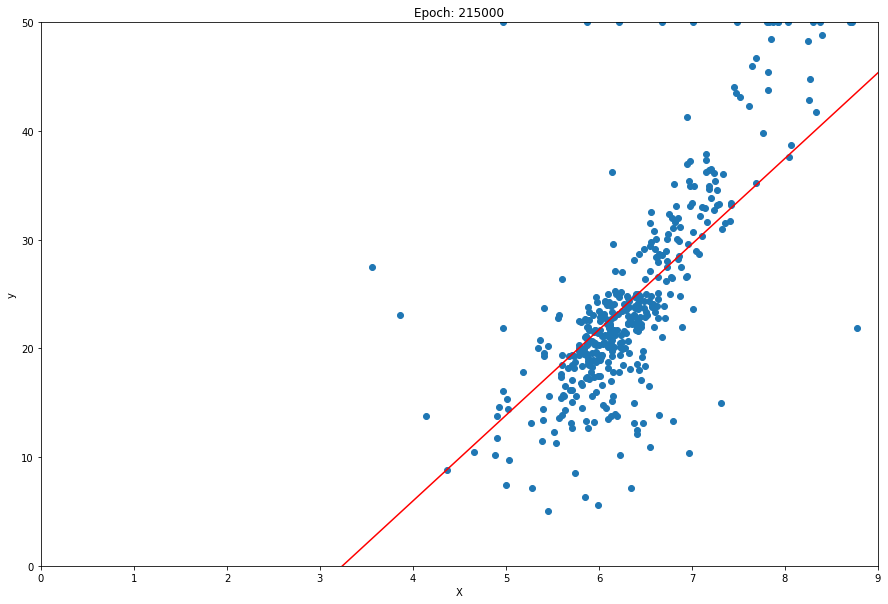

epoch:  220000 average loss:  38.979975504036794


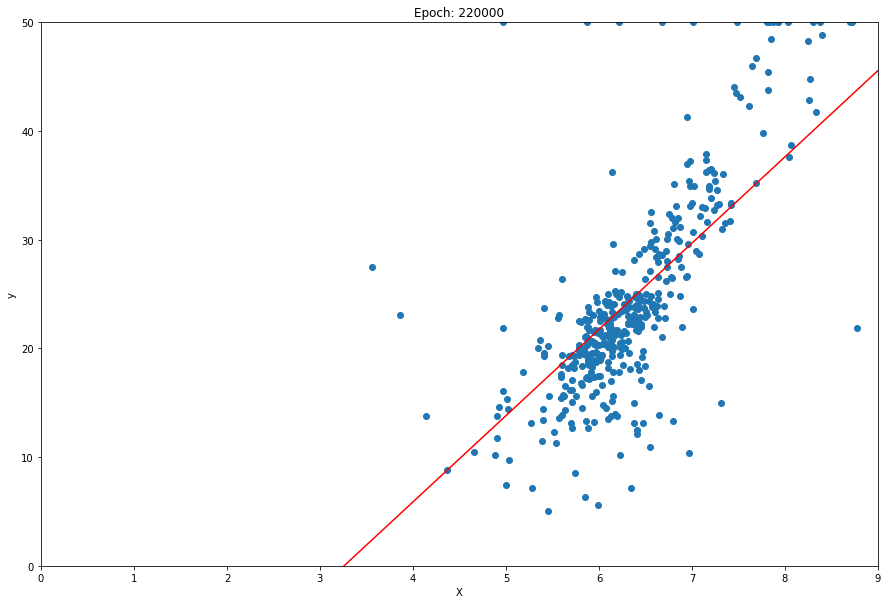

epoch:  225000 average loss:  38.89397696323782


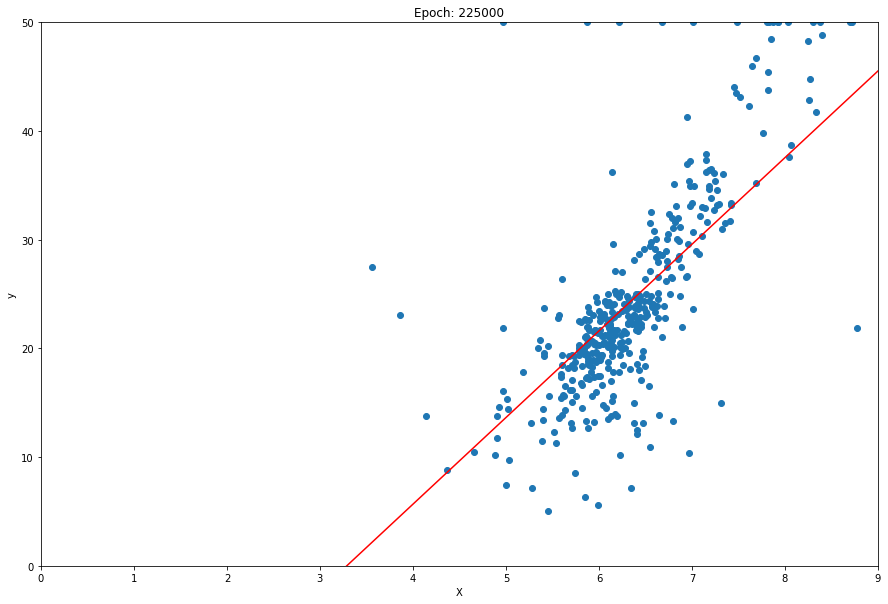

epoch:  230000 average loss:  38.81764229010376


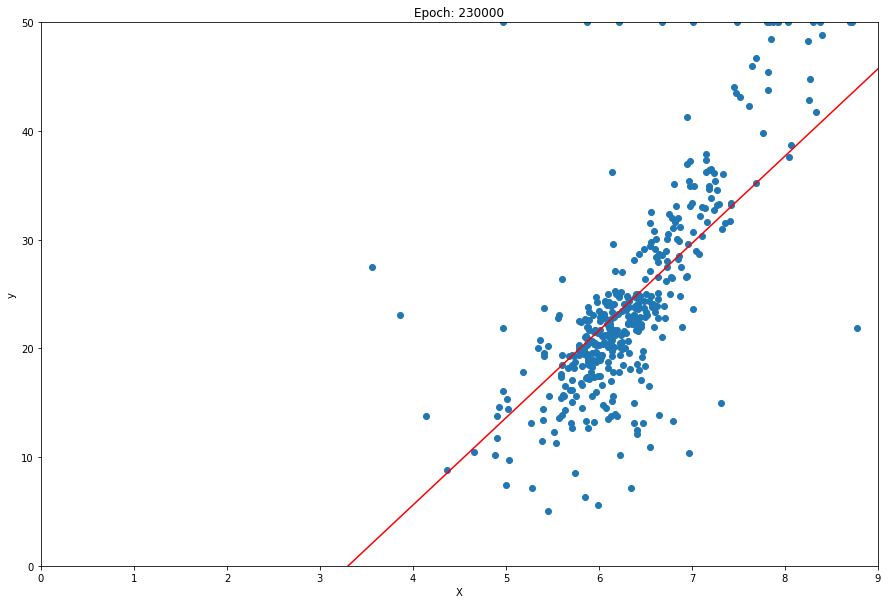

epoch:  235000 average loss:  38.747447568105876


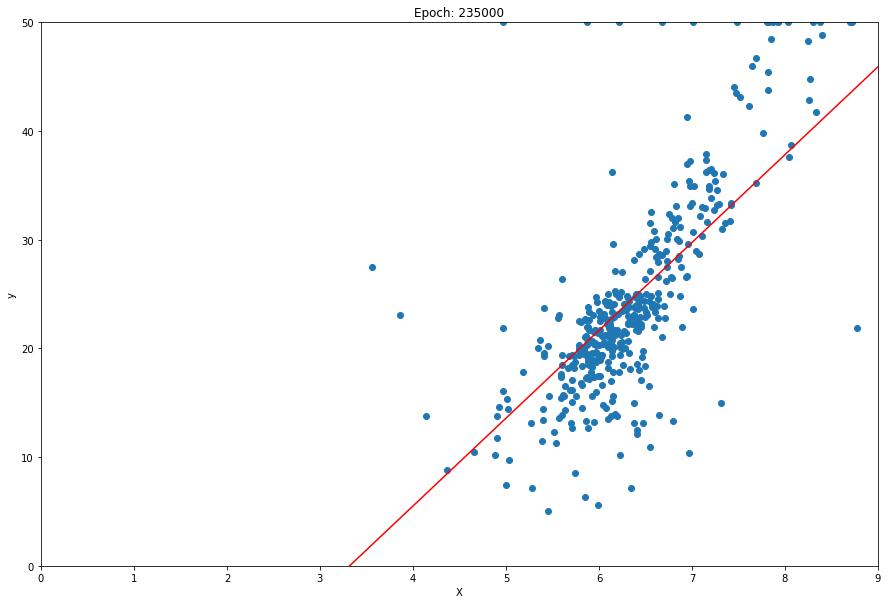

epoch:  240000 average loss:  38.685428687030395


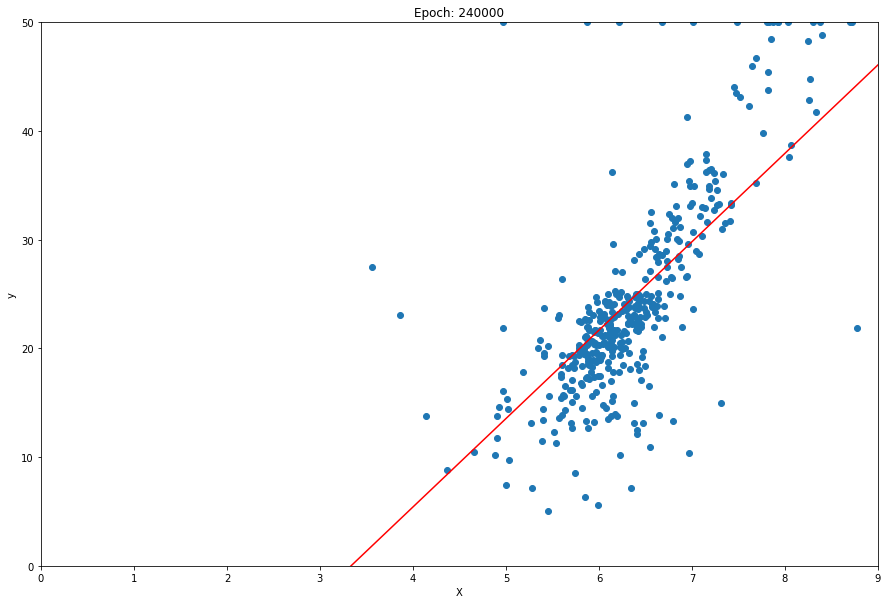

epoch:  245000 average loss:  38.61852897797838


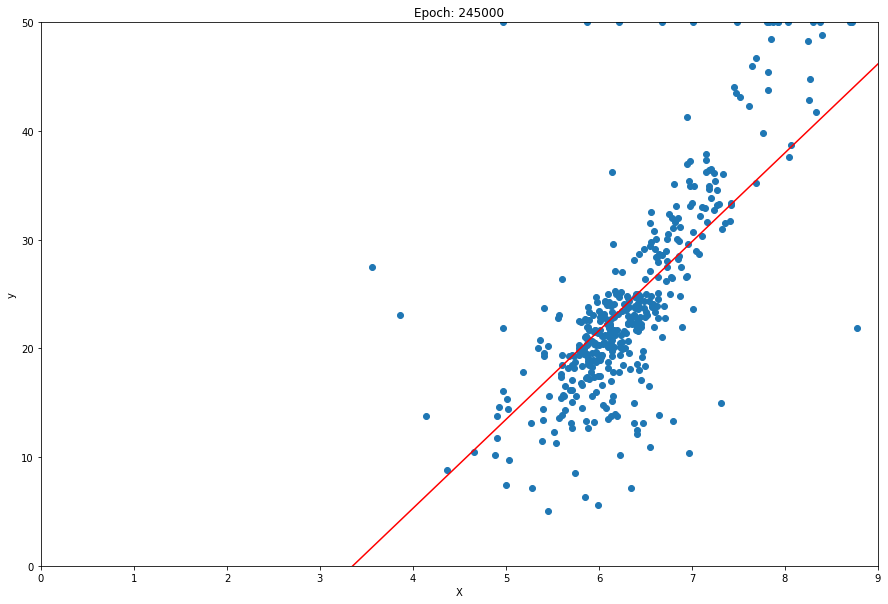

epoch:  250000 average loss:  38.55850520872722


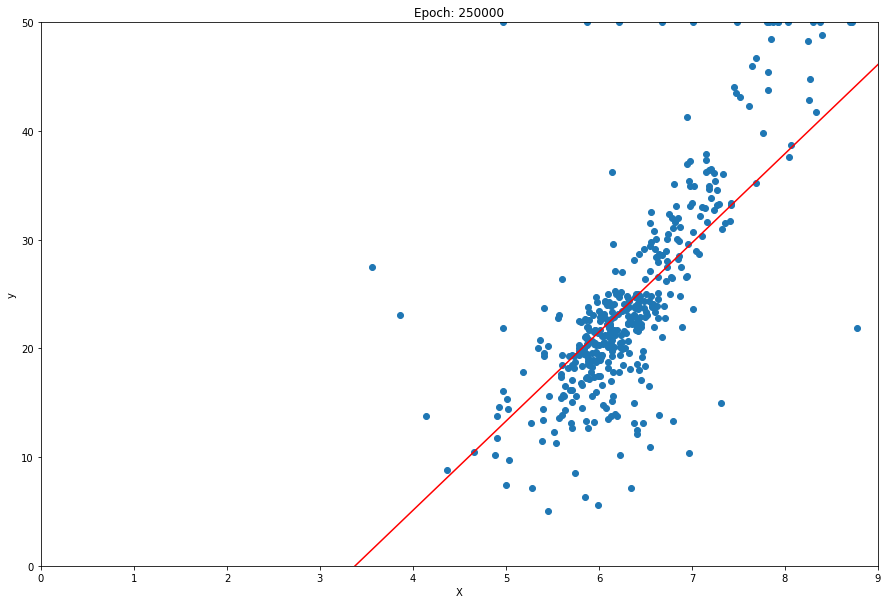

epoch:  255000 average loss:  38.500766496520725


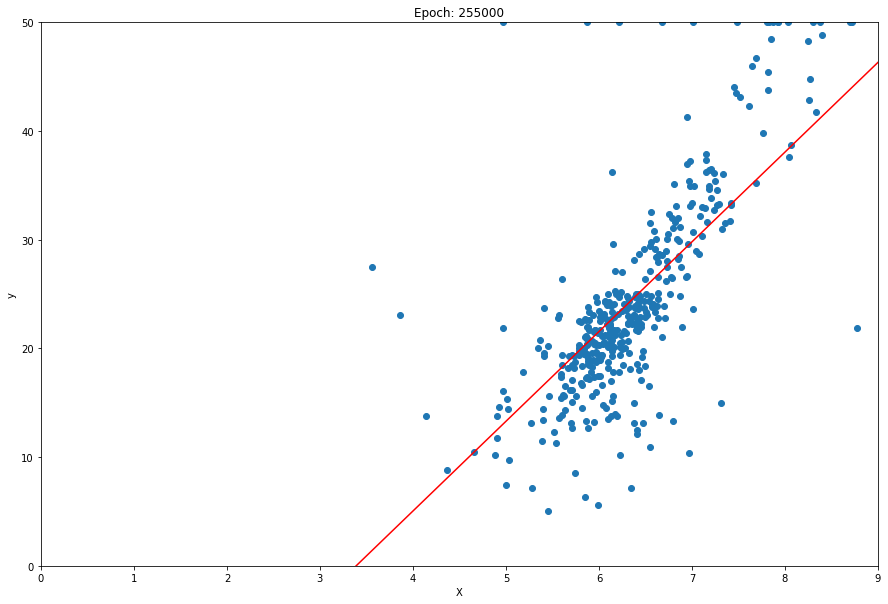

epoch:  260000 average loss:  38.44827754172928


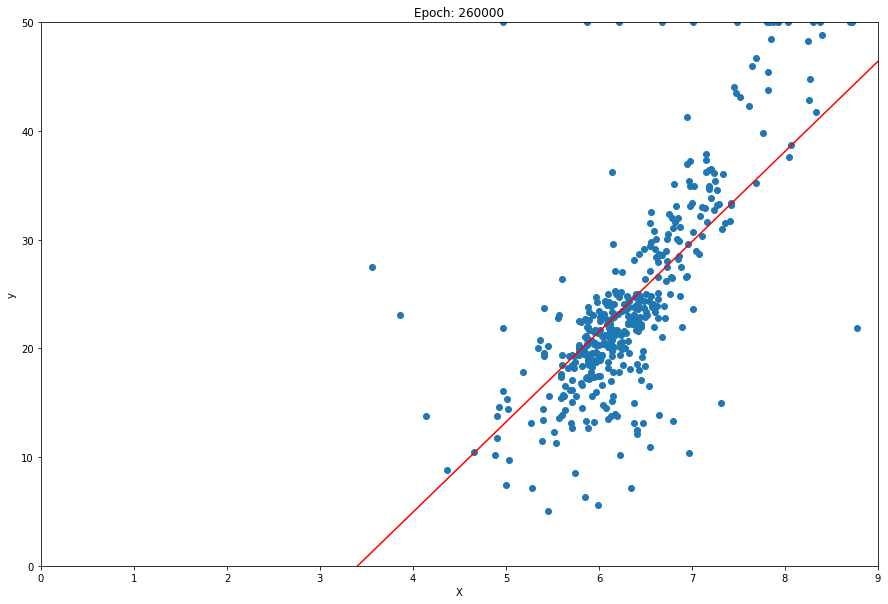

epoch:  265000 average loss:  38.40441967135508


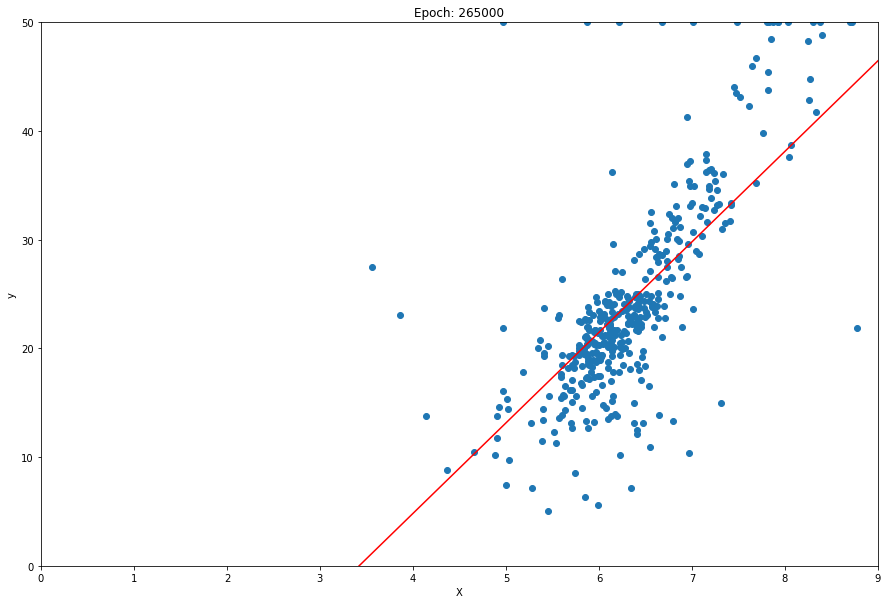

epoch:  270000 average loss:  38.35967143928555


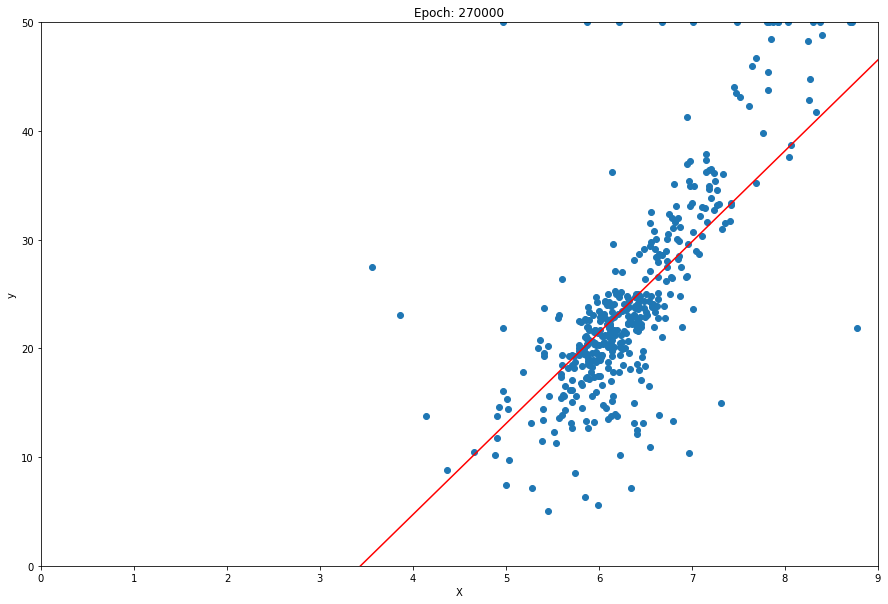

epoch:  275000 average loss:  38.32273032257742


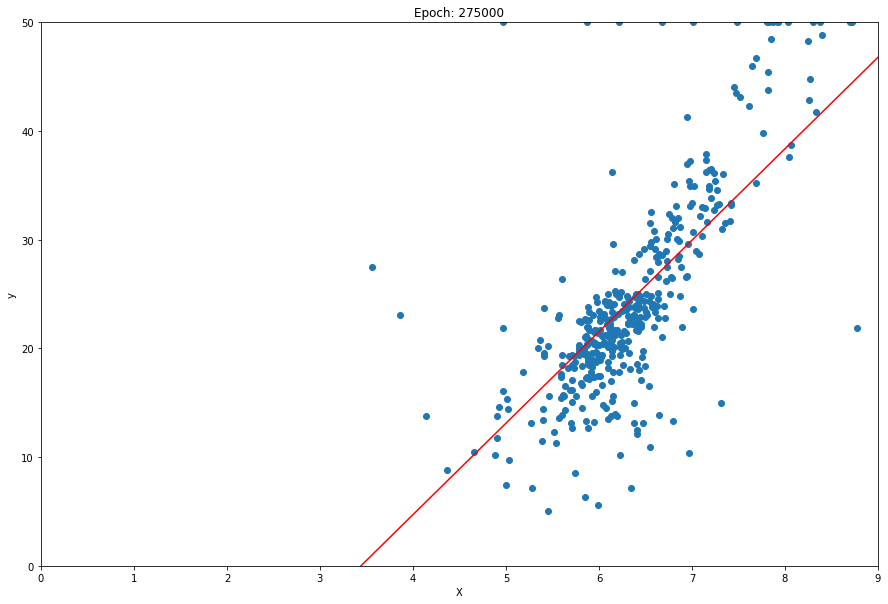

epoch:  280000 average loss:  38.3117236041394


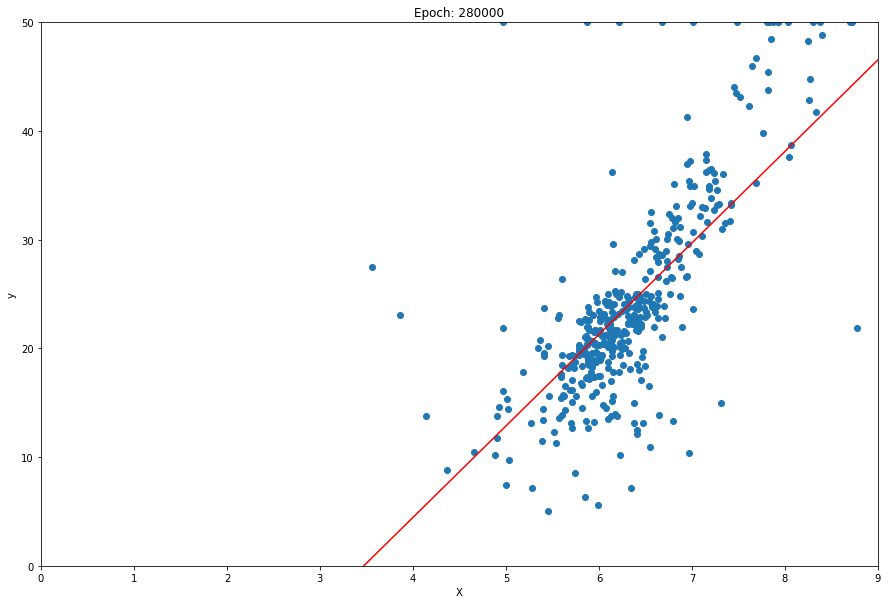

epoch:  285000 average loss:  38.24843940917856


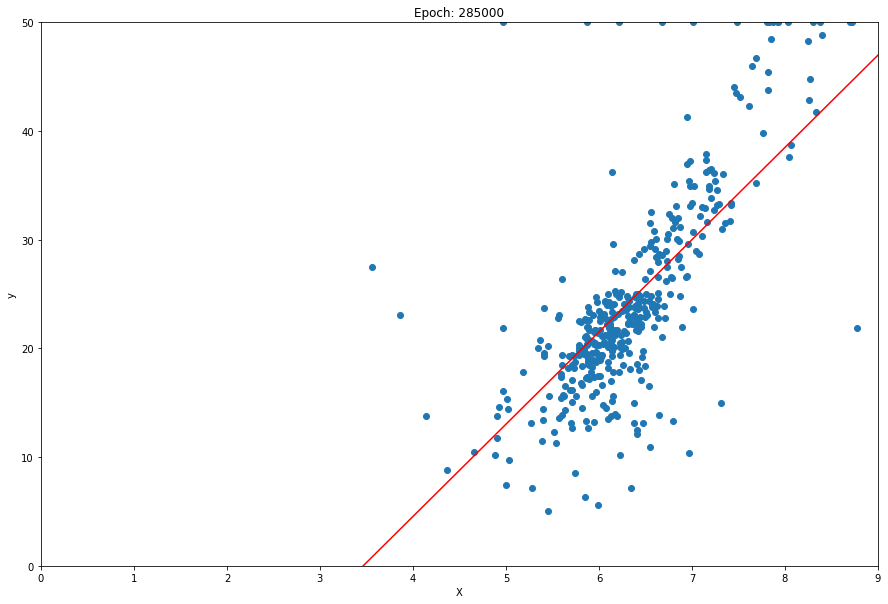

epoch:  290000 average loss:  38.210907047657535


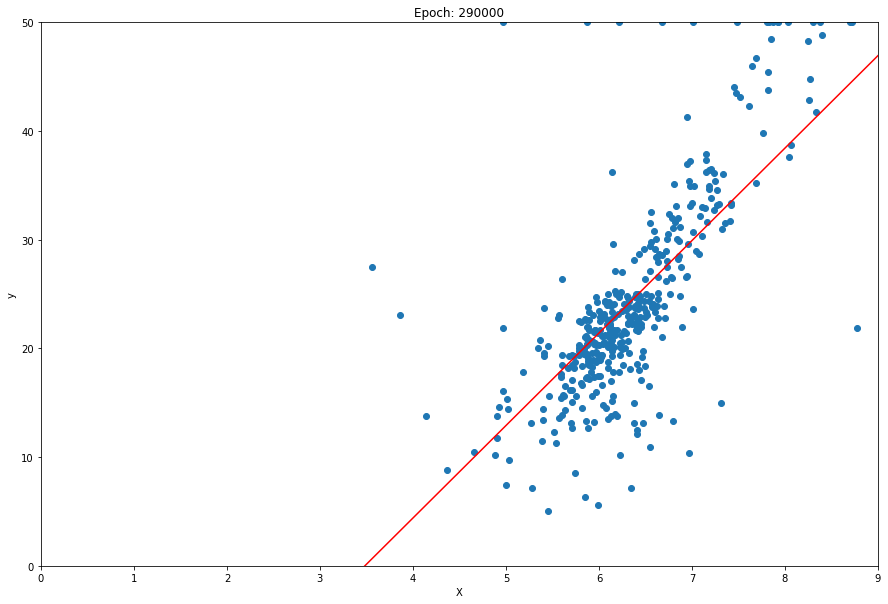

epoch:  295000 average loss:  38.18084318869424


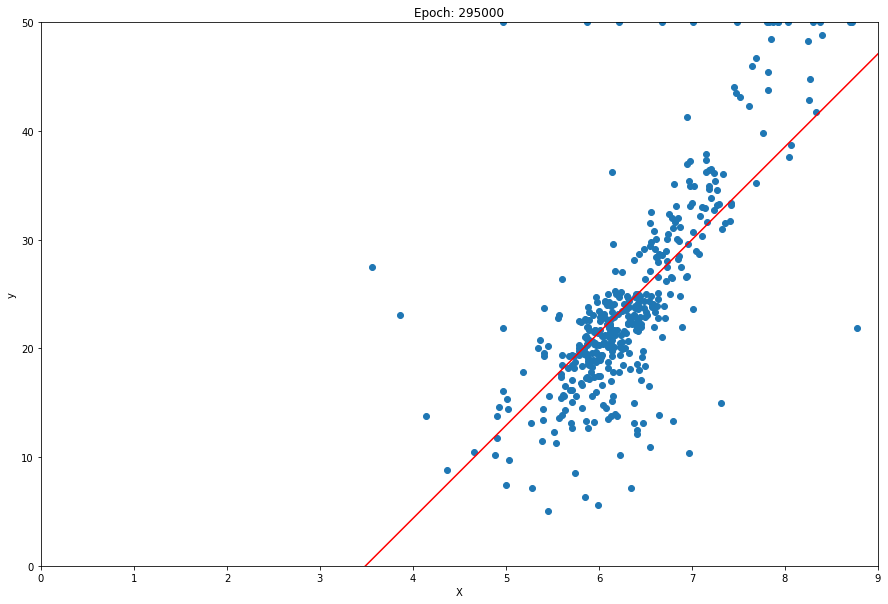

epoch:  300000 average loss:  38.15735347794809


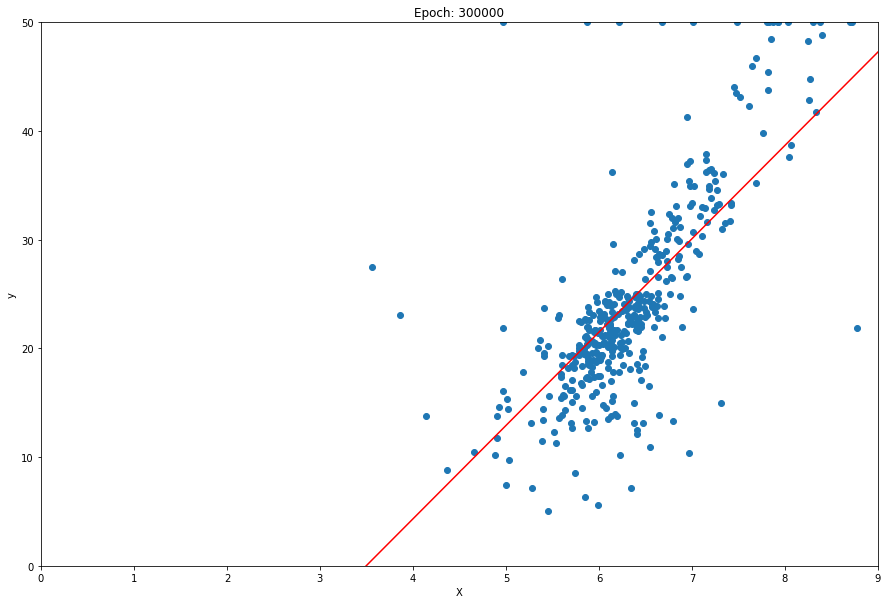

epoch:  305000 average loss:  38.1532895329967


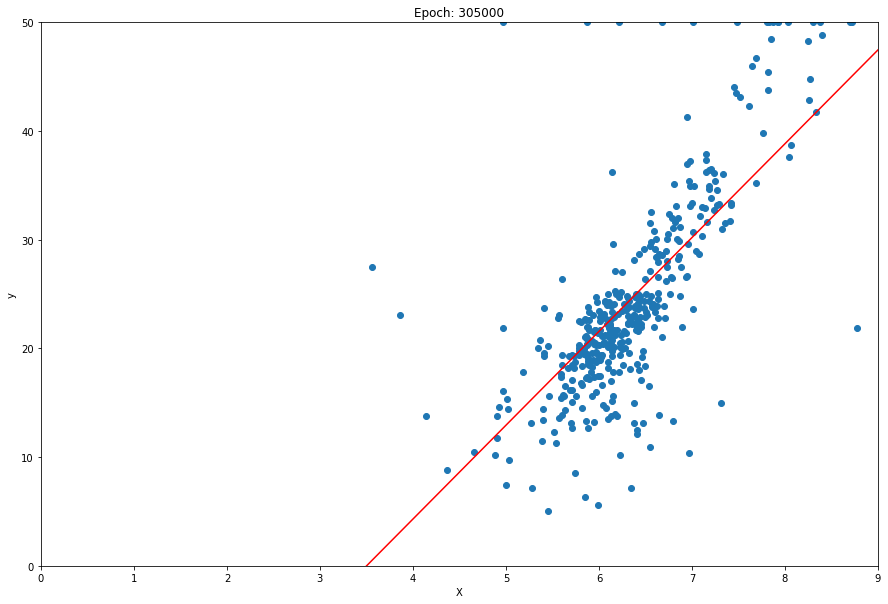

epoch:  310000 average loss:  38.094752998237375


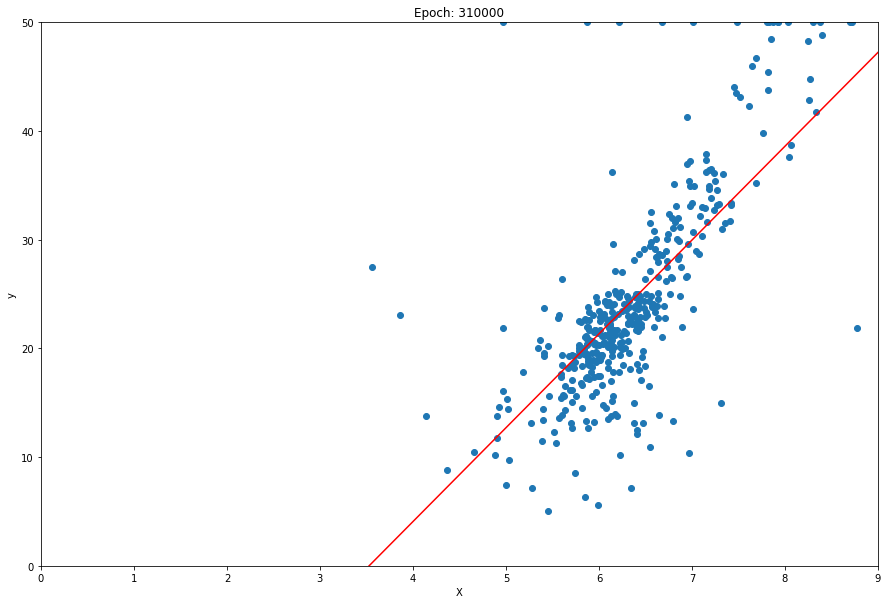

epoch:  315000 average loss:  38.06927830523437


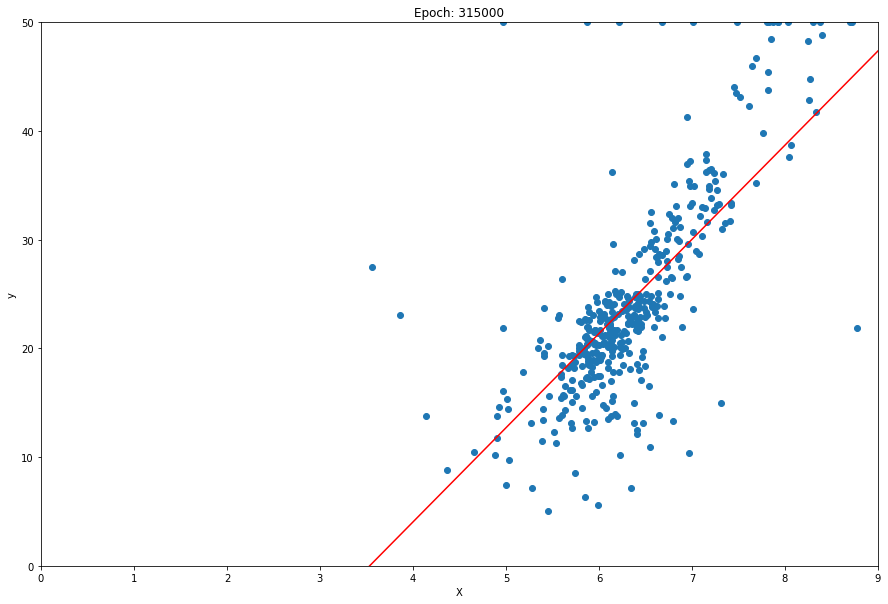

epoch:  320000 average loss:  38.051768324706565


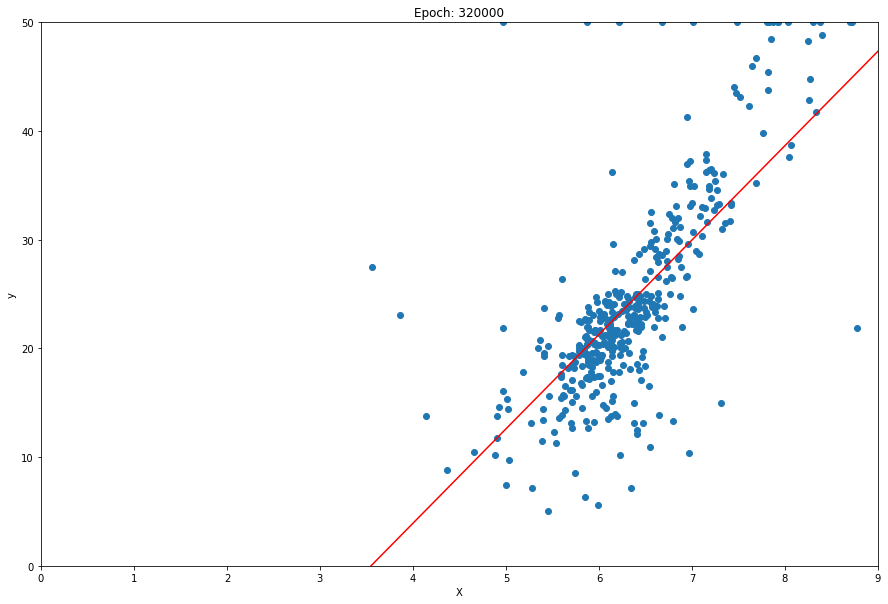

epoch:  325000 average loss:  38.0243565688333


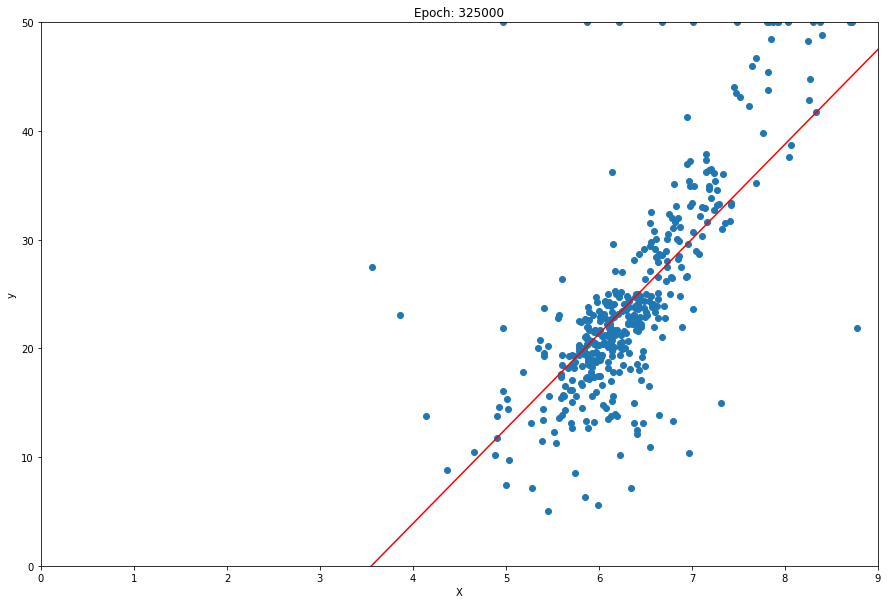

epoch:  330000 average loss:  38.02195978783199


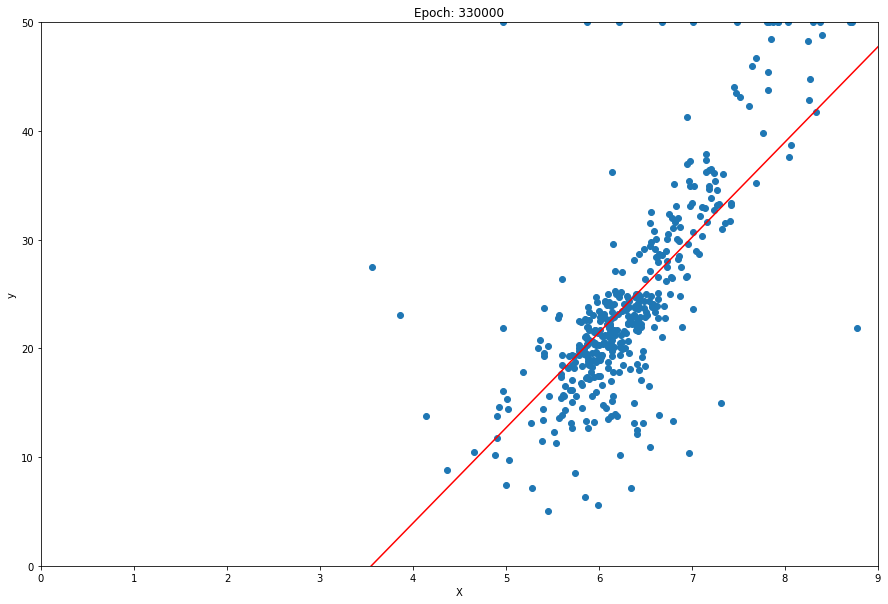

epoch:  335000 average loss:  37.99462936606528


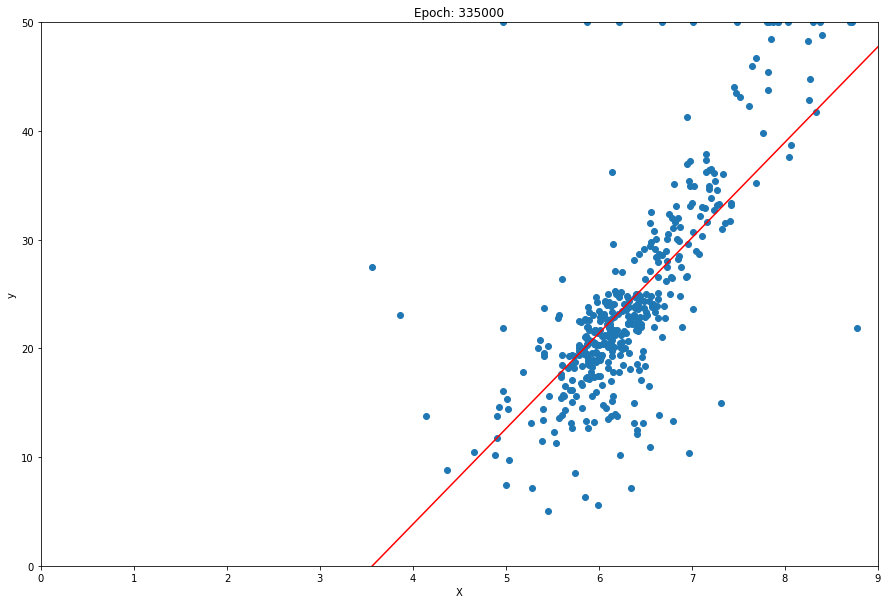

380.55338621139526


In [15]:
import time
start_time = time.time()
w_list, b_list, avg_loss_list, w, b, img_list, pred_val_at_diff_epoch = train(df["RM"][0:403], df["MEDV"][0:403], 0, 0, 0.001, 1000000, 0.9, 0.99, 0.0000001)
print(f"{time.time() - start_time}")

In [16]:
print(len(w_list))
print(len(b_list))
print(len(avg_loss_list))
print("best value for w: ",w)
print("best value for b: ",b)
print(len(img_list))
print(len(pred_val_at_diff_epoch))

33501
33501
33501
best value for w:  8.78198779378794
best value for b:  -31.296757306736897
68
0


In [17]:
len(avg_loss_list)*10

335010

In [18]:
min(avg_loss_list)

37.988917340997254

In [19]:
n = np.linspace(10, 33501, 33501, endpoint = True)
len(n)

33501

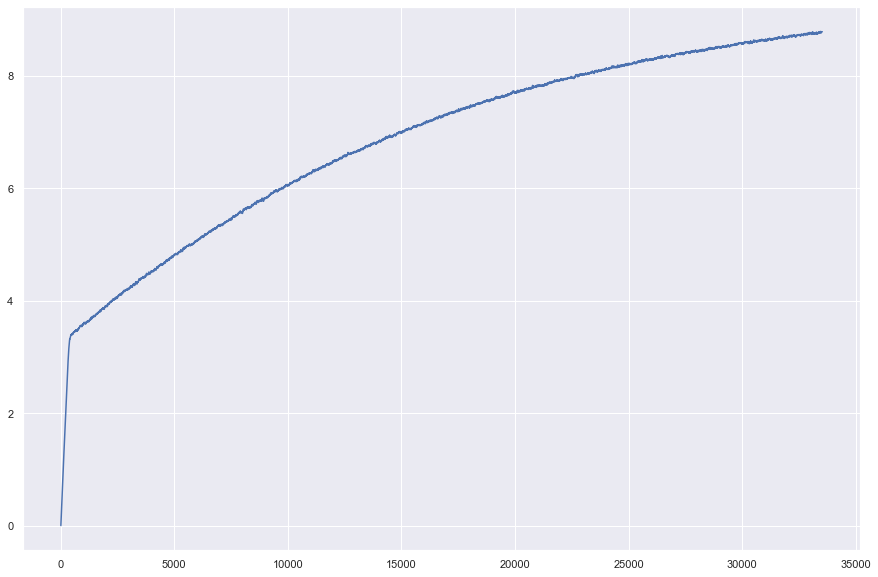

In [20]:
sns.set(rc = {"figure.figsize" : (15, 10)})
plt.plot(n, w_list)
plt.show()

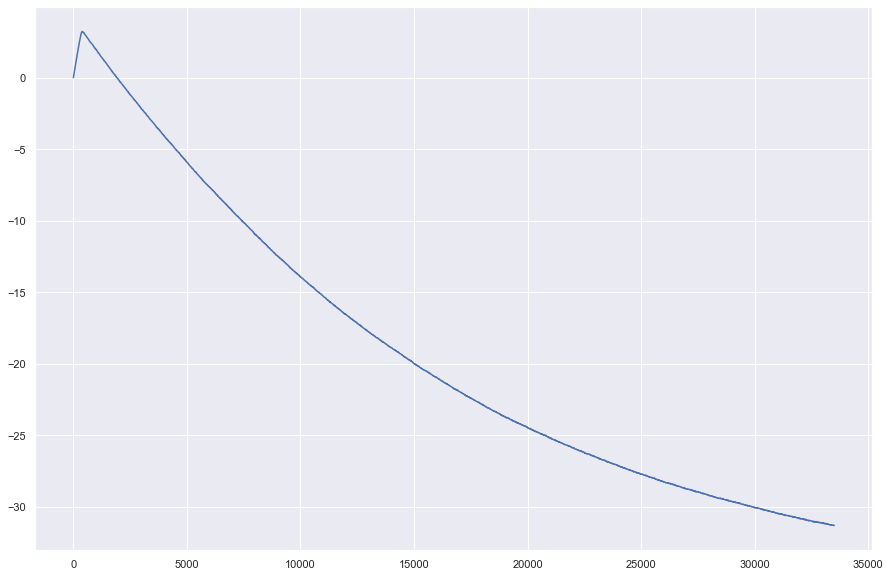

In [21]:
plt.plot(n, b_list)
plt.show()

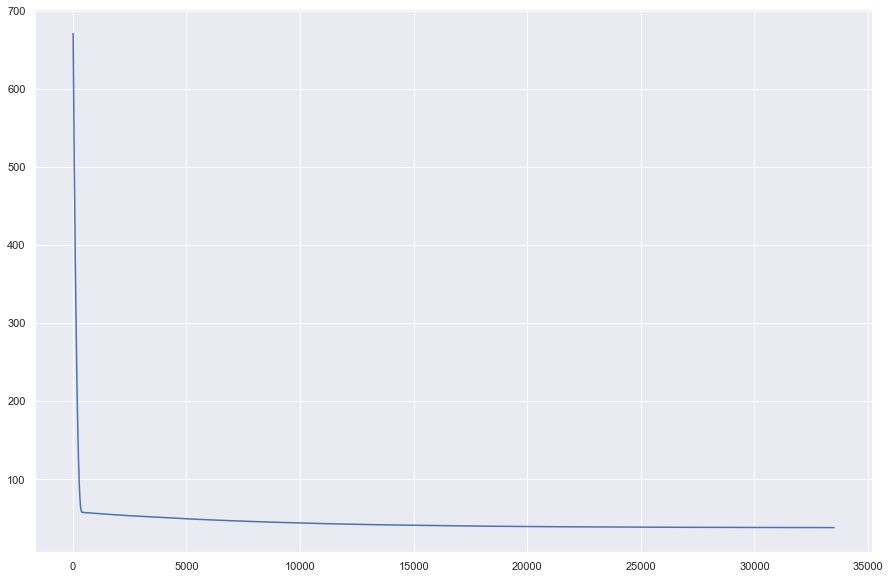

In [22]:
plt.plot(n, avg_loss_list)
plt.show()

In [23]:
predicted_vals = []
for feature in df["RM"]:
    predicted_vals.append(predict(feature, w, b))

In [24]:
predictedY_vs_realY = pd.DataFrame()

In [25]:
predictedY_vs_realY["REAL Y"] = df["MEDV"]
predictedY_vs_realY["PREDICTED Y"] = predicted_vals
predictedY_vs_realY["ERROR"] = abs(predictedY_vs_realY["REAL Y"] - predictedY_vs_realY["PREDICTED Y"])

In [26]:
predictedY_vs_realY.head()

,REAL Y,PREDICTED Y,ERROR
0,24.0,26.444812,2.444812
1,21.6,25.092386,3.492386
2,34.7,31.801825,2.898175
3,33.4,30.159593,3.240407
4,36.2,31.468109,4.731891


In [27]:
import imageio
with imageio.get_writer('gradient_descent_01.gif', mode='I') as writer:
    for filename in img_list:
        image = imageio.imread(filename)
        writer.append_data(image)